In [ ]:
!pip uninstall anomalib -y

Found existing installation: anomalib 2.2.0
Uninstalling anomalib-2.2.0:
  Successfully uninstalled anomalib-2.2.0


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\Rowan\\Documents\\Rowan\\Yolo_test\\final_env_yolo\\Lib\\site-packages\\cv2\\cv2.pyd'
Check the permissions.

You should consider upgrading via the 'C:\Users\Rowan\Documents\Rowan\Yolo_test\final_env_yolo\Scripts\python.exe -m pip install --upgrade pip' command.


In [ ]:
!pip install --user anomalib==0.7.0

ERROR: Can not perform a '--user' install. User site-packages are not visible in this virtualenv.
You should consider upgrading via the 'C:\Users\Rowan\Documents\Rowan\Yolo_test\final_env_yolo\Scripts\python.exe -m pip install --upgrade pip' command.


In [ ]:
!pip uninstall numpy -y


In [ ]:
pip install numpy==1.23.5

Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
albucore 0.0.24 requires numpy>=1.24.4, but you have numpy 1.23.5 which is incompatible.
albumentations 2.0.8 requires numpy>=1.24.4, but you have numpy 1.23.5 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.23.5 which is incompatible.
opencv-python-headless 4.13.0.90 requires numpy>=2; python_version >= "3.9", but you have numpy 1.23.5 which is incompatible.
roboflow 1.2.11 requires opencv-python-headless==4.10.0.84, but you have opencv-python-headless 4.13.0.90 which is incompatible.
scikit-image 0.25.2 requires numpy>=1.24, but you have numpy 1.23.5 which is incompatible.
tensorflow 2.20.0 requires numpy>=1.26.0, but you have numpy 1.23.5 which is incompatible.


   ---------------------------------------- 0.0/14.6 MB ? eta -:--:--
    --------------------------------------- 0.3/14.6 MB ? eta -:--:--
   -- ------------------------------------- 1.0/14.6 MB 4.6 MB/s eta 0:00:03
   --------- ------------------------------ 3.4/14.6 MB 7.5 MB/s eta 0:00:02
   ------------- -------------------------- 5.0/14.6 MB 7.7 MB/s eta 0:00:02
   ----------------- ---------------------- 6.3/14.6 MB 7.3 MB/s eta 0:00:02
   -------------------- ------------------- 7.3/14.6 MB 7.0 MB/s eta 0:00:02
   ---------------------- ----------------- 8.1/14.6 MB 6.5 MB/s eta 0:00:02
   ----------------------- ---------------- 8.7/14.6 MB 6.0 MB/s eta 0:00:01
   ------------------------- -------------- 9.4/14.6 MB 5.6 MB/s eta 0:00:01
   --------------------------- ------------ 10.2/14.6 MB 5.3 MB/s eta 0:00:01
   ----------------------------- ---------- 10.7/14.6 MB 5.2 MB/s eta 0:00:01
   ------------------------------- -------- 11.5/14.6 MB 5.0 MB/s eta 0:00:01
   -------

In [ ]:
import os
import shutil
import random
from pathlib import Path

# ==========================================================
# USER CONFIGURATION
# ==========================================================
# CHANGE THESE PATHS to point to your existing folders in Kaggle
# Example: "/kaggle/input/my-dataset/clean"
CLEAN_SOURCE = r"C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\cropped_clean_using_yo8s_1280" 
CLEAN_SOURCE2 = r"C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\some_healthy_from_mixed_after_yolo8s" 

DEFECT_SOURCE = r"C:\Users\Rowan\Documents\Rowan\Yolo_test\cells_by_class\crack"

# Where we will create the new organized dataset
OUTPUT_ROOT = r"C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\cropped_organized_dataset_crack"

# Split ratio: 70% Clean for Training, 20% Clean for Validation
TRAIN_RATIO = 0.7

def organize_dataset():
    print(f"--- Organizing Dataset ---")
    
    # 1. Create Directory Structure
    # We need:
    # /pv_organized_dataset/train/good/
    # /pv_organized_dataset/test/good/
    # /pv_organized_dataset/test/defect/
    
    train_good_dir = os.path.join(OUTPUT_ROOT, "train", "good")
    test_good_dir = os.path.join(OUTPUT_ROOT, "test", "good")
    test_defect_dir = os.path.join(OUTPUT_ROOT, "test", "defect")
    
    for folder in [train_good_dir, test_good_dir, test_defect_dir]:
        if os.path.exists(folder):
            shutil.rmtree(folder)
        else:
            os.makedirs(folder, exist_ok=True)
        
    # 2. Process Clean Images (Split into Train/Test)
    clean_files = []
    valid_exts = ('.jpg', '.jpeg', '.png', '.bmp')
    
    if os.path.exists(CLEAN_SOURCE):
        for f in os.listdir(CLEAN_SOURCE):
            if f.lower().endswith(valid_exts):
                clean_files.append(os.path.join(CLEAN_SOURCE, f))
    else:
        print(f"Warning: Clean source path not found: {CLEAN_SOURCE}")

    if os.path.exists(CLEAN_SOURCE2):
        for f in os.listdir(CLEAN_SOURCE2):
            if f.lower().endswith(valid_exts):
                clean_files.append(os.path.join(CLEAN_SOURCE2, f))
    else:
        print(f"Warning: Clean source path not found: {CLEAN_SOURCE2}")

    print(f"Found {len(clean_files)} clean images.")
    
    random.shuffle(clean_files)
    
    split_idx = int(len(clean_files) * TRAIN_RATIO)
    
    train_clean = clean_files[:split_idx]
    test_clean = clean_files[split_idx:]
    
    # Copy Train Clean
    for f in train_clean:
        shutil.copy(f, os.path.join(train_good_dir, os.path.basename(f)))
        
    # Copy Test Clean (for Thresholding/FPR)
    for f in test_clean:
        shutil.copy(f, os.path.join(test_good_dir, os.path.basename(f)))
        
    # 3. Process Defect Images (All go to Test/Defect)
    defect_files = []
    if os.path.exists(DEFECT_SOURCE):
        for f in os.listdir(DEFECT_SOURCE):
            if f.lower().endswith(valid_exts):
                defect_files.append(os.path.join(DEFECT_SOURCE, f))
    else:
        print(f"Warning: Defect source path not found: {DEFECT_SOURCE}")

    print(f"Found {len(defect_files)} defect images.")
    
    for f in defect_files:
        shutil.copy(f, os.path.join(test_defect_dir, os.path.basename(f)))

    print(f"✅ Dataset organized successfully at: {OUTPUT_ROOT}")
    print(f"   Train Good: {len(train_clean)}")
    print(f"   Test Good:   {len(test_clean)}")
    print(f"   Test Defect: {len(defect_files)}")

organize_dataset()

--- Organizing Dataset ---
Found 5660 clean images.
Found 1264 defect images.
✅ Dataset organized successfully at: C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\cropped_organized_dataset_crack
   Train Good: 3961
   Test Good:   1699
   Test Defect: 1264


In [ ]:
import torch
from anomalib.models import Patchcore
from anomalib.data import Folder
from anomalib.engine import Engine
from anomalib import TaskType
from torchvision.transforms import v2

# -----------------------------
# Transforms (VERY IMPORTANT)
# -----------------------------
image_transform = v2.Compose([
    v2.Resize((256, 256)),
    v2.Grayscale(num_output_channels=1),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.5], std=[0.5]),
])

# -----------------------------
# Dataset
# -----------------------------
datamodule = Folder(
    root=OUTPUT_ROOT,
    normal_dir="good",
    abnormal_dir=None,      # PatchCore trains ONLY on normal
    # image_size=(256, 256),
    train_batch_size=8,
    eval_batch_size=8,
    image=image_transform,          # <-- THIS is correct

)

# -----------------------------
# Model
# -----------------------------
model = Patchcore(
    backbone="resnet18",
    layers=["layer2", "layer3"],
    pre_trained=True,
    coreset_sampling_ratio=0.1,
)

# -----------------------------
# Engine
# -----------------------------
engine = Engine(
    task=TaskType.ANOMALY,
    default_root_dir="./patchcore_runs"
)

# -----------------------------
# Train
# -----------------------------
engine.fit(
    datamodule=datamodule,
    model=model
)

# -----------------------------
# Save model + memory bank
# -----------------------------
engine.export(
    model=model,
    export_type="torch"
)

c:\Users\Rowan\Documents\Rowan\Yolo_test\final_env_yolo\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'anomalib.engine'

In [ ]:
import os
import torch
from torch.utils.data import Dataset
import cv2

class PVCellDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = []
        self.labels = []

        for label, subfolder in enumerate(["train/good", "test/defect"]):
            folder_path = os.path.join(root_dir, subfolder)
            for fname in os.listdir(folder_path):
                if fname.lower().endswith((".png",".jpg")):
                    self.images.append(os.path.join(folder_path, fname))
                    self.labels.append(label)  # 0 = normal, 1 = defective
                
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (256,256))
        if self.transform:
            img = self.transform(img)
        else:
            img = torch.tensor(img/255., dtype=torch.float32).unsqueeze(0)
        label = self.labels[idx]
        return img, label

In [ ]:
import torch.nn as nn
from torchvision import models

class FeatureExtractor(nn.Module):
    def __init__(self, device="cuda"):
        super().__init__()
        self.device = device
        resnet = models.resnet18(pretrained=True)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        self.backbone.to(device)
        self.backbone.eval()
    
    def forward(self, x):
        if x.shape[1]==1:  # grayscale -> 3 channels
            x = x.repeat(1,3,1,1)
        with torch.no_grad():
            feats = self.backbone(x)
        B,C,H,W = feats.shape
        return feats.view(B,H*W,C).permute(0,1,2)  # [B, HW, C]

In [ ]:
from torch.utils.data import DataLoader
from sklearn.neighbors import NearestNeighbors
import numpy as np
from tqdm import tqdm

dataset = PVCellDataset(r"C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\cropped_organized_dataset_crack\train")
dataloader = DataLoader(dataset, batch_size=8, shuffle=False)
device = "cuda" if torch.cuda.is_available() else "cpu"
feature_extractor = FeatureExtractor(device=device)

all_features = []
for imgs in tqdm(dataloader):
    imgs = imgs.to(device)
    feats = feature_extractor(imgs)
    feats = feats.reshape(-1, feats.shape[-1])
    all_features.append(feats.cpu().numpy())

all_features = np.concatenate(all_features, axis=0)

# Coreset sampling
coreset_ratio = 0.1
idx = np.random.choice(all_features.shape[0],
                       size=int(all_features.shape[0]*coreset_ratio),
                       replace=False)
memory_bank = all_features[idx]
np.save("memory_bank.npy", memory_bank)

100%|██████████| 496/496 [00:04<00:00, 111.58it/s]


In [ ]:
def patchcore_infer(img_tensor, feature_extractor, memory_bank, threshold, device="cpu"):
    img_tensor = img_tensor.to(device)
    if img_tensor.shape[1]==1:
        img_tensor = img_tensor.repeat(1,3,1,1)
    feats = feature_extractor(img_tensor)
    feats = feats.reshape(-1, feats.shape[-1]).cpu().numpy()
    from sklearn.neighbors import NearestNeighbors
    nn_model = NearestNeighbors(n_neighbors=1)
    nn_model.fit(memory_bank)
    dist = nn_model.kneighbors(feats, return_distance=True)[0].flatten()
    anomaly_score = dist.mean()
    is_anomaly = anomaly_score > threshold
    return anomaly_score, is_anomaly

In [ ]:
nn_model = NearestNeighbors(n_neighbors=1)
nn_model.fit(memory_bank)

distances = nn_model.kneighbors(memory_bank, return_distance=True)[0].flatten()
threshold = np.percentile(distances, 95)

import json
with open("threshold.json","w") as f:
    json.dump({"threshold": float(threshold)}, f)

In [ ]:
torch.save(feature_extractor.backbone.state_dict(), "backbone.pt")

In [ ]:
def hybrid_infer(img_path, feature_extractor, memory_bank, threshold):
    import cv2
    import torch
    import numpy as np
    from sklearn.neighbors import NearestNeighbors

    # Load image
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img_resized = cv2.resize(img, (256,256))
    tensor_img = torch.tensor(img_resized/255., dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    
    device = next(feature_extractor.parameters()).device
    tensor_img = tensor_img.to(device)
    if tensor_img.shape[1]==1:
        tensor_img = tensor_img.repeat(1,3,1,1)
    
    # Feature extraction
    feats = feature_extractor(tensor_img)  # PyTorch model
    feats = feats.reshape(-1, feats.shape[-1]).cpu().numpy()

    # kNN search in memory bank
    nn_model = NearestNeighbors(n_neighbors=1)
    nn_model.fit(memory_bank)
    dist = nn_model.kneighbors(feats, return_distance=True)[0].flatten()
    
    anomaly_score = dist.mean()
    is_anomaly = anomaly_score > threshold

    # YOLO detection
    # yolo_results = yolo_model.predict(img_path, verbose=False)
    # boxes = yolo_results[0].boxes.xyxy.cpu().numpy() if len(yolo_results) else []

    return {
        "anomaly_score": float(anomaly_score),
        "is_anomaly": bool(is_anomaly),
        # "boxes": boxes,
        "image": img
    }

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Load memory bank & threshold
memory_bank = np.load("memory_bank.npy")
with open("threshold.json") as f:
    threshold = json.load(f)["threshold"]

device = "cuda" if torch.cuda.is_available() else "cpu"
feature_extractor = FeatureExtractor(device=device)
feature_extractor.backbone.load_state_dict(torch.load("backbone.pt", map_location=device))

# Load test dataset
test_dataset = PVCellDataset(r"C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\cropped_organized_dataset_crack")
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

y_true = []
y_pred = []
scores = []

for img, label in test_loader:
    score, pred = patchcore_infer(img, feature_extractor, memory_bank, threshold, device=device)
    y_true.append(label.item())
    y_pred.append(int(pred))
    scores.append(score)

# Compute metrics
acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auroc = roc_auc_score(y_true, scores)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"AUROC: {auroc:.4f}")

c:\Users\Rowan\Documents\Rowan\Yolo_test\final_env_yolo\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Rowan\Documents\Rowan\Yolo_test\final_env_yolo\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\Rowan\AppData\Local\Temp\ipykernel_19560\2582061838.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpi

MemoryError: bad allocation

In [ ]:
import numpy as np
import torch
from ultralytics import YOLO

# Load PatchCore artifacts . old
memory_bank = np.load("memory_bank.npy")
with open("threshold.json") as f:
    threshold = json.load(f)["threshold"]
feature_extractor = FeatureExtractor(device="cpu")
feature_extractor.backbone.load_state_dict(torch.load("backbone.pt"))  # optional save from training

# Load YOLO
# yolo_model = YOLO("yolov8_pv.pt")

result = hybrid_infer(r"C:\Users\Rowan\Documents\Rowan\Yolo_test\cells_by_class\crack\2image-2-_jpg.rf.c2cb81f6563db64341959022380334ed_cell_18.jpg",
                      feature_extractor, memory_bank, threshold)

print("Score:", result["anomaly_score"], "Anomaly:", result["is_anomaly"])
# print("Detected boxes:", result["boxes"])

Score: 9.124495089054108 Anomaly: True


c:\Users\Rowan\Documents\Rowan\Yolo_test\final_env_yolo\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Rowan\Documents\Rowan\Yolo_test\final_env_yolo\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\Rowan\AppData\Local\Temp\ipykernel_19560\251604169.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpic

In [ ]:
result = hybrid_infer(r"C:\Users\Rowan\Documents\Rowan\Yolo_test\cells_by_class\crack\2image_jpg.rf.b5177246ef89598544a3ce679241dd0f_cell_59.jpg",
                      feature_extractor, memory_bank, threshold)

print("Score:", result["anomaly_score"], "Anomaly:", result["is_anomaly"])

Score: 6.375337120145559 Anomaly: True


In [ ]:
import pickle
import faiss
import gc

import torch.nn as nn

In [ ]:
class ELAnomalyConfig:
    def __init__(self):
        self.img_size = 256
        self.backbone = 'resnet18'
        self.n_neighbors = 5
        self.threshold_percentile = 98  # Threshold for validation
        self.max_patches_per_level = 50000
        self.use_cpu_index = True
        # Robust Scoring Settings
        self.top_k_percent = 0.10 # Use top 10% of patches for scoring (Focus on anomalies)
        
    def save(self, path):
        with open(path, 'w') as f:
            json.dump(self.dict, f, indent=2)
    
    @classmethod
    def load(cls, path):
        config = cls()
        with open(path, 'r') as f:
            config_dict = json.load(f)
        config.__dict__.update(config_dict)
        return config

class ELFeatureExtractor(nn.Module):
    def __init__(self, backbone='resnet18', pretrained=True):
        super().__init__()
        if backbone == 'resnet18':
            base_model = models.resnet18(weights="DEFAULT" if pretrained else None)
            self.feature_dims = [64, 128, 256, 512]
        elif backbone == 'resnet50':
            base_model = models.resnet50(weights="DEFAULT" if pretrained else None)
            self.feature_dims = [256, 512, 1024, 2048]
        
        self.conv1 = base_model.conv1
        self.bn1 = base_model.bn1
        self.relu = base_model.relu
        self.maxpool = base_model.maxpool
        self.layer1 = base_model.layer1
        self.layer2 = base_model.layer2
        self.layer3 = base_model.layer3
        self.layer4 = base_model.layer4
        
        # Freeze early layers if desired, but usually fine-tuning helps EL data.
        # We'll keep them eval mode (no grad) by default as per your code.
        for p in self.parameters():
            p.requires_grad = False
        self.eval()
    
    def forward(self, x, return_patches=False):
        with torch.no_grad():
            x = self.conv1(x)
            x = self.bn1(x)
            x = self.relu(x)
            x = self.maxpool(x)
            f1 = self.layer1(x)
            f2 = self.layer2(f1)
            f3 = self.layer3(f2)
            f4 = self.layer4(f3)
            
            if return_patches:
                patches = {}
                for level, feat in zip(['level1', 'level2', 'level3', 'level4'], [f1, f2, f3, f4]):
                    B, C, H, W = feat.shape
                    # Normalize patch vectors L2
                    feat_norm = feat / (feat.norm(dim=1, keepdim=True) + 1e-10)
                    patches[level] = feat_norm.permute(0, 2, 3, 1).reshape(-1, C)
                return patches
            return {'level1': f1, 'level2': f2, 'level3': f3, 'level4': f4}

# ==================== Optimized Memory Bank (Keep as is) ====================
class ELMemoryBank:
    def __init__(self, config: ELAnomalyConfig):
        self.config = config
        self.indexes = {}
        self.patch_stats = {}
        self.feature_dims = {}
    
    def build(self, dataloader, extractor: ELFeatureExtractor, device):
        print("Building memory bank...")
        level_patches = {level: [] for level in ['level1', 'level2', 'level3', 'level4']}
        extractor.eval()
        
        with torch.no_grad():
            for batch_idx, batch in enumerate(tqdm(dataloader, desc="Extracting patches")):
                batch = batch.to(device)
                patches = extractor(batch, return_patches=True)
                
                for level in ['level1', 'level2', 'level3', 'level4']:
                    if level in patches:
                        level_patches[level].append(patches[level].cpu())
                
                if batch_idx % 10 == 0 and torch.cuda.is_available():
                    torch.cuda.empty_cache()
                
                if sum(len(p) for p in level_patches.values()) > self.config.max_patches_per_level * 2:
                     break
        
        for level in ['level1', 'level2', 'level3', 'level4']:
            if level_patches[level]:
                all_patches = torch.cat(level_patches[level], dim=0).numpy()
                
                if len(all_patches) > self.config.max_patches_per_level:
                    indices = np.random.choice(len(all_patches), self.config.max_patches_per_level, replace=False)
                    all_patches = all_patches[indices]
                
                d = all_patches.shape[1]
                index = faiss.IndexFlatL2(d)
                index.add(all_patches)
                
                self.indexes[level] = index
                self.feature_dims[level] = d
                self.patch_stats[level] = len(all_patches)
                del all_patches
                gc.collect()
        
        return self
    
class ELAnomalyDetectorZ:
    def __init__(self, config=None, device=None):
        self.config = config or ELAnomalyConfig()
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.extractor = None
        self.memory_bank = None
        self.threshold = None
        self.validation_stats = None
    
    
    def predict(self, image_path):
        self.extractor.eval()
        
        # 1. Preprocess (Uses OpenCV resize, matching training)
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise ValueError(f"Failed to load {image_path}")
            
        # Apply same normalization/CLAHE as dataset
        img = self._normalize(img)
        img = cv2.resize(img, (self.config.img_size, self.config.img_size))
        img = np.stack([img]*3, axis=-1)
        
        # To Tensor & Normalize (-1 to 1)
        img_tensor = T.ToTensor()(img)
        img_tensor = (img_tensor - 0.5) / 0.5
        img_tensor = img_tensor.unsqueeze(0).to(self.device)
        
        # 2. Score
        score = self._compute_single_score(img_tensor)
        
        return score > self.threshold, float(score)

    def _normalize(self, img):
        # Duplicate logic from dataset for inference to ensure consistency
        img = img.astype(np.float32)
        p1, p99 = np.percentile(img, [1, 99])
        img = np.clip(img, p1, p99)
        img = (img - img.min()) / (img.max() - img.min() + 1e-10) * 255
        img = np.clip(img, 0, 255).astype(np.uint8)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        return clahe.apply(img)

    def _compute_single_score(self, img_tensor):
        with torch.no_grad():
            patches = self.extractor(img_tensor, return_patches=True)
        
        level_scores = []
        for level in ['level1', 'level2', 'level3', 'level4']:
            if level in self.memory_bank.indexes:
                feat = patches[level].cpu().numpy()
                D, _ = self.memory_bank.indexes[level].search(feat, self.config.n_neighbors)
                
                # Mean of neighbors
                patch_dists = D.mean(axis=1)
                
                # Top-K Mean
                k = max(1, int(len(patch_dists) * self.config.top_k_percent))
                top_k = np.partition(patch_dists, -k)[-k:]
                level_scores.append(top_k.mean())
        
        # Max across levels
        return max(level_scores) if level_scores else 0.0


    @classmethod
    def load(cls, path_dir, device=None):
        device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        # Load Config
        config = ELAnomalyConfig.load(os.path.join(path_dir, 'config.json'))
        detector = cls(config, device)
        
        # Load Threshold
        with open(os.path.join(path_dir, 'model_info.json'), 'r') as f:
            info = json.load(f)
        detector.threshold = info['threshold']
        
        # Load Extractor
        ckpt = torch.load(os.path.join(path_dir, 'extractor.pth'), map_location=device, weights_only=False)
        detector.extractor = ELFeatureExtractor(backbone=ckpt['backbone'], pretrained=False)
        detector.extractor.load_state_dict(ckpt['state_dict'])
        detector.extractor.to(device)
        detector.extractor.eval()
        
        # Load Memory Bank
        with open(os.path.join(path_dir, 'memory_bank.pkl'), 'rb') as f:
            mb_data = pickle.load(f)
        detector.memory_bank = ELMemoryBank(config)
        detector.memory_bank.patch_stats = mb_data['patch_stats']
        detector.memory_bank.feature_dims = mb_data['feature_dims']
        
        # Load Indexes
        for level in ['level1', 'level2', 'level3', 'level4']:
            idx_path = os.path.join(path_dir, f'faiss_{level}.index')
            if os.path.exists(idx_path):
                detector.memory_bank.indexes[level] = faiss.read_index(idx_path)
        
        print(f"Model loaded. Threshold: {detector.threshold:.6f}")
        return detector

In [ ]:
import torch
import os, json
import torchvision.models as models

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
path_dir = r"C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\kaggle\working\z_model"

# Load Config
config = ELAnomalyConfig.load(os.path.join(path_dir, 'config.json'))

model = ELAnomalyDetectorZ.load(path_dir)

Model loaded. Threshold: 0.535159


In [ ]:
import torchvision.transforms as T

In [ ]:
import os
import cv2
import torch
import numpy as np
import shutil

# 2. Setup Output for "Suspect" images
os.makedirs('suspect_images', exist_ok=True)

# 3. Run on Validation Set
val_root = r"C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\combined_clean_and_some"

image_files = []
for root, _, files in os.walk(val_root):
    for f in files:
        if f.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_files.append(os.path.join(root, f))

print(f"Scanning {len(image_files)} healthy images...")

scores = []
for img_path in image_files:
    is_defect, score = model.predict(img_path)
    scores.append((score, img_path))

# 4. Sort by Score (Highest = Most Suspect)
scores.sort(key=lambda x: x[0], reverse=True)

# 5. Analyze and Copy Top 50 "Suspects"
top_k = 50
print(f"\n{'='*60}")
print(f"TOP {top_k} MOST ANOMALOUS 'HEALTHY' IMAGES")
print(f"{'='*60}")
print(f"Threshold: {model.threshold:.4f}")
print(f"These images are statistically 'weird'. Check if they are actually bad quality.\n")



Scanning 5660 healthy images...

TOP 50 MOST ANOMALOUS 'HEALTHY' IMAGES
Threshold: 0.5352
These images are statistically 'weird'. Check if they are actually bad quality.



ValueError: Unknown format code 'f' for object of type 'str'

In [ ]:
for i, (score, path) in enumerate(scores[:top_k]):
    filename = os.path.basename(path)
    
    # Copy file to suspect folder for inspection
    shutil.copy(path, f'suspect_images/{i}_{filename}')
    
    # print(f"{i+1}. Score: {score:.4f} | {filename}")

1. Score: 0.9282 | DSC_3369_cell143.jpg
2. Score: 0.8374 | DSC_1335_cell130.jpg
3. Score: 0.7097 | B070_png.rf.15aea10e7954097e592476d5059b3e4d_cell30.jpg
4. Score: 0.6799 | 1961_1966_D211AABB3A20210298_png.rf.a1c46ac16b44a35e7d7bb07edefb6c24_cell3.jpg
5. Score: 0.6532 | DSC_0948_cell0.jpg
6. Score: 0.6430 | 000024_jpg.rf.0ddb4c6b03598d03e7651d47d7a94c0a_cell106.jpg
7. Score: 0.6428 | 000036_JPG.rf.f39011834dc5c5c43e8346b9a9cb4721_cell72.jpg
8. Score: 0.6353 | 000720_jpg.rf.bd904451db7808e0e498c3232c076cf1_cell53.jpg
9. Score: 0.6256 | 000721_JPG.rf.8862904964a8d3835b1f3949d1aaa9a7_cell2.jpg
10. Score: 0.6168 | 000090_jpg.rf.70b6ae78c094093bea2f11eb6e9b7ed6_cell75.jpg
11. Score: 0.6148 | 000090_jpg.rf.70b6ae78c094093bea2f11eb6e9b7ed6_cell73.jpg
12. Score: 0.6147 | DSC_0833_cell2.jpg
13. Score: 0.6105 | B069_png.rf.3185b618faf7f01ab28810d5b8f0a80e_cell71.jpg
14. Score: 0.6079 | 000738_png.rf.2bc740a319809f83e02a945043ca98e1_cell50.jpg
15. Score: 0.5978 | 000720_jpg.rf.bd904451db7808e0e4

In [ ]:
import numpy as np

@torch.no_grad()
def patchcore_score(
    img_tensor,
    extractor,
    memory_bank,
    n_neighbors=5,
    top_k=50
):
    extractor.eval()

    _, multi_feat = extractor(img_tensor)

    per_level_maps = []

    for level in LEVELS:
        feat = multi_feat[level]        # [1, C, H, W]
        _, C, H, W = feat.shape

        feat = feat.permute(0,2,3,1).reshape(-1, C)
        feat = feat / (feat.norm(dim=1, keepdim=True) + 1e-10)
        feat_np = feat.cpu().numpy()

        D, _ = memory_bank.indexes[level].search(feat_np, n_neighbors)

        k = min(top_k, D.shape[1])
        patch_scores = np.mean(np.sort(D, axis=1)[:, -k:], axis=1)
        patch_map = patch_scores.reshape(H, W)

        per_level_maps.append(patch_map)

    # 🔥 Max across levels (industry standard)
    final_map = np.max(np.stack(per_level_maps, axis=0), axis=0)

    # Image-level anomaly score
    image_score = float(final_map.mean())

    return image_score, final_map

In [ ]:
def predict_image(
    image_path,
    extractor,
    memory_bank,
    threshold,
    device,
    img_size=512
):
    img_tensor = preprocess_image(image_path, img_size, device)

    score, heatmap = patchcore_score(
        img_tensor,
        extractor,
        memory_bank
    )

    is_defective = score > threshold
    return is_defective, score, heatmap

In [ ]:
import matplotlib.pyplot as plt

def visualize_result(image_path, heatmap, score, threshold):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

    heatmap_color = plt.cm.jet(heatmap)[:,:,:3]
    heatmap_color = (heatmap_color * 255).astype(np.uint8)

    overlay = cv2.addWeighted(img, 0.6, heatmap_color, 0.4, 0)

    plt.figure(figsize=(6,6))
    plt.title(f"Score={score:.4f} | Threshold={threshold:.4f}")
    plt.imshow(overlay)
    plt.axis('off')
    plt.show()

In [ ]:
with open(os.path.join(path_dir, 'model_info.json'), 'r') as f:
    info = json.load(f)
threshold = info['threshold']

# Load Extractor
ckpt = torch.load(os.path.join(path_dir, 'extractor.pth'), map_location=device, weights_only=False)
extractor = ELFeatureExtractor(backbone=ckpt['backbone'], pretrained=False)
extractor.load_state_dict(ckpt['state_dict'])
extractor.to(device)
extractor.eval()

ELFeatureExtractor(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inpl

In [ ]:
import torch.nn.functional as F

@torch.no_grad()
def extract_features(img_tensor):
    feats = extractor(img_tensor)

    outputs = {}
    for level in ["level1", "level2", "level3", "level4"]:
        f = feats[level]                       # B,C,H,W
        f = F.normalize(f, dim=1)

        B, C, H, W = f.shape
        f = f.permute(0, 2, 3, 1).reshape(-1, C)  # (B*H*W, C)
        outputs[level] = f.cpu().numpy()

    return outputs

In [ ]:
import cv2
import numpy as np
import torch
import torchvision.transforms as T

LEVELS = [1, 2, 3, 4]

def preprocess_image(image_path, img_size=256):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Cannot read image: {image_path}")

    # --- SAME normalization as training ---
    img = img.astype(np.float32)
    p1, p99 = np.percentile(img, [1, 99])
    img = np.clip(img, p1, p99)
    img = (img - img.min()) / (img.max() - img.min() + 1e-10) * 255
    img = img.astype(np.uint8)

    clahe = cv2.createCLAHE(2.0, (8,8))
    img = clahe.apply(img)

    img = cv2.resize(img, (img_size, img_size))
    img = np.stack([img]*3, axis=-1)

    transform = T.Compose([
        T.ToTensor(),
        T.Normalize(mean=[0.485,0.456,0.406],
                    std =[0.229,0.224,0.225])
    ])

    img = transform(img).unsqueeze(0).to(device)
    return img

In [ ]:
import faiss
faiss_dir = r"C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\kaggle\working\z_model\\"
faiss_indexes = {
    "level1": faiss.read_index(faiss_dir +"faiss_level1.index"),
    "level2": faiss.read_index(faiss_dir +"faiss_level2.index"),
    "level3": faiss.read_index(faiss_dir +"faiss_level3.index"),
    "level4": faiss.read_index(faiss_dir +"faiss_level4.index"),
}

# sanity check
for k, idx in faiss_indexes.items():
    print(k, "dim:", idx.d)


level1 dim: 64
level2 dim: 128
level3 dim: 256
level4 dim: 512


In [ ]:
def compute_anomaly_score(feature_dict, faiss_indexes, k=5, top_k=10):
    all_patch_scores = []

    for level, feat_np in feature_dict.items():
        index = faiss_indexes[level]

        D, _ = index.search(feat_np, k)   # (num_patches, k)
        patch_scores = np.mean(np.sort(D, axis=1)[:, -top_k:], axis=1)

        all_patch_scores.append(patch_scores)

    return float(np.max(np.concatenate(all_patch_scores)))

In [ ]:
def predict_image(
    image_path,
    extractor,
    faiss_indexes,
    threshold,
    device
):
    img = preprocess_image(image_path).to(device)

    feats = extract_features(img)
    score = compute_anomaly_score(feats, faiss_indexes)

    prediction = "DEFECTIVE" if score > threshold else "GOOD"

    return prediction, score

In [ ]:

pred, score = predict_image(
    # r"C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\some_healthy_from_mixed_after_yolo8s\0image-3-_jpg.rf.34a4425a9bfee178d324d723a9fdb6f0_cell29.jpg",
    r"C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\some_healthy_from_mixed_after_yolo8s\C210AAAB3A20170895_png.rf.73371eb6ab6d7ea52adc6d75240f01b8_cell44.jpg",
    extractor,
    faiss_indexes,
    threshold+0.1,
    device
)

print(f"Prediction: {pred} | Score: {score:.4f}")

Prediction: DEFECTIVE | Score: 0.7230


In [ ]:
pip uninstall numpy -y

Found existing installation: numpy 2.2.6
Uninstalling numpy-2.2.6:
  Successfully uninstalled numpy-2.2.6
Note: you may need to restart the kernel to use updated packages.


You can safely remove it manually.
You can safely remove it manually.


In [ ]:
pip install numpy==1.26.4

   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   - -------------------------------------- 0.5/15.8 MB 4.2 MB/s eta 0:00:04
   ----- ---------------------------------- 2.1/15.8 MB 6.9 MB/s eta 0:00:02
   ---------- ----------------------------- 4.2/15.8 MB 8.1 MB/s eta 0:00:02
   ------------- -------------------------- 5.2/15.8 MB 8.2 MB/s eta 0:00:02
   --------------- ------------------------ 6.3/15.8 MB 7.4 MB/s eta 0:00:02
   ----------------- ---------------------- 7.1/15.8 MB 6.6 MB/s eta 0:00:02
   ------------------- -------------------- 7.9/15.8 MB 5.9 MB/s eta 0:00:02
   --------------------- ------------------ 8.4/15.8 MB 5.7 MB/s eta 0:00:02
   ----------------------- ---------------- 9.2/15.8 MB 5.3 MB/s eta 0:00:02
   ------------------------ --------------- 9.7/15.8 MB 5.1 MB/s eta 0:00:02
   -------------------------- ------------- 10.5/15.8 MB 5.0 MB/s eta 0:00:02
   ---------------------------- ----------- 11.3/15.8 MB 4.8 MB/s eta 0:00:01
   -

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.90 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
roboflow 1.2.11 requires opencv-python-headless==4.10.0.84, but you have opencv-python-headless 4.13.0.90 which is incompatible.


In [ ]:
# old model in integration
from anomalib.deploy import TorchInferencer
import torch

from anomalib.models.image.patchcore import Patchcore

anomaly_model = TorchInferencer(
    path="models/cell_anomaly.pt", 
    device="cuda" if torch.cuda.is_available() else "cpu"
)
CELL_ANOM_THRESH = 0.5


c:\Users\Rowan\Documents\Rowan\Yolo_test\final_env_yolo\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TypeError: Patchcore.__init__() got an unexpected keyword argument 'pre_processor'

In [ ]:
import sys
import anomalib.models as models

# Create an alias so PyTorch can find the old module path
sys.modules['anomalib.models.image'] = models

In [ ]:
import torch

In [ ]:
from anomalib.models import Patchcore

# 1. Initialize the model shell
# In v1.2.0, pre_processor is part of the model's internal logic
model = Patchcore()

# 2. Load your weights
# If your .pt is a state_dict
state_dict = torch.load("models/cell_anomaly.pt", map_location="cpu")
model.load_state_dict(state_dict)

C:\Users\Rowan\AppData\Local\Temp\ipykernel_4136\1559874120.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("models/cell_anomaly.pt", map_locatio

ModuleNotFoundError: No module named 'anomalib.pre_processing'

In [ ]:
import torch
import io
import sys

# 1. Define a generic "Dummy" class that returns itself for any attribute access
# This prevents AttributeErrors if the loader tries to access specific classes/functions
class DummyModule:
    def __getattr__(self, attr):
        return DummyModule()
    def __call__(self, *args, **kwargs):
        return DummyModule()

# 2. Inject the dummy module into sys.modules for the missing path
sys.modules['anomalib.pre_processing'] = DummyModule()

# 3. Load the file
try:
    with open("models/cell_anomaly.pt", "rb") as f:
        buffer = io.BytesIO(f.read())
        
        # This will now skip the missing import and return the dictionary
        checkpoint = torch.load(buffer, map_location="cpu")
        checkpoint.load_state_dict(state_dict)

    print("Keys found in checkpoint:")
    print(checkpoint.keys())

except Exception as e:
    print(f"An error occurred: {e}")

# 4. Clean up (optional)
if 'anomalib.pre_processing' in sys.modules:
    del sys.modules['anomalib.pre_processing']

An error occurred: 'DummyModule' object is not iterable


C:\Users\Rowan\AppData\Local\Temp\ipykernel_4136\3355683161.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(buffer, map_location="cpu")


In [ ]:
import torch

# try:
with open("models/cell_anomaly.pt", "rb") as f:
    # weights_only=True skips the unpickling of non-tensor objects
    checkpoint = torch.load(f, map_location="cpu", weights_only=True)

print(checkpoint.keys())

# except Exception as e:
#     print("Error (Note: 'weights_only' might fail if the file contains pure Python objects):", e)

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL anomalib.models.image.padim.lightning_model.Padim was not an allowed global by default. Please use `torch.serialization.add_safe_globals([Padim])` to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types accepted by default with weights_only https://pytorch.org/docs/stable/generated/torch.load.html.

In [ ]:
# pip install anomalib==1.2.0
# !pip install open-clip-torch
import anomalib
print(anomalib.__version__)

1.2.0


In [ ]:
float(anomaly_model.predict(image=cell_img).pred_score)

In [ ]:
threshold

0.5351585149765015

In [ ]:
from anomalib.data import Folder
from anomalib import TaskType
from anomalib.models.image import Patchcore, Padim  # ✅ Correct for Anomalib 1.0
from anomalib.engine import Engine

In [ ]:
# 1. Setup the Data
# Make sure your folders are organized as shown above
datamodule = Folder(
    root=r"C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\\",   # Path to the folder containing 'train' and 'test'
    image_size=(256, 256),
    # Anomalib 1.0 assumes category name is 'good' by default
    normal_dir="combined_clean_and_some",   
    name="good_anomaly", 
    task=TaskType.CLASSIFICATION
)

# 2. Setup the Model
model = Padim(
    # You can lower 'backbone' if it runs too slow, e.g., "resnet18"
    backbone="wide_resnet50_2", 
    # layers to extract features from (default is good for EL)
    layers=["layer2", "layer3"], 
)

# 3. Setup the Engine (Trainer)
engine = Engine(
    max_epochs=1,  # PatchCore is unsupervised, it builds a memory bank in 1 pass
    accelerator="auto", # Uses GPU if available
    devices=1,
)

# 4. Train
print("Training (building memory bank)...")
engine.fit(model, datamodule=datamodule)

# 5. Test
print("Testing on bad images...")
test_results = engine.test(model, datamodule=datamodule)

# 6. (Optional) Run prediction on a single image to visualize
# from anomalib.data.utils import read_image
# predictions = engine.predict(model, img)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
`Trainer(val_check_interval=1.0)` was configured so validation will run at the end of the training epoch..


Training (building memory bank)...


You are using a CUDA device ('NVIDIA GeForce RTX 4060') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
F1Score class exists for backwards compatibility. It will be removed in v1.1. Please use BinaryF1Score from torchmetrics instead
F1Score class exists for backwards compatibility. It will be removed in v1.1. Please use BinaryF1Score from torchmetrics instead
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\Rowan\Documents\Rowan\Yolo_test\final_env_yolo\lib\site-packages\lightning\pytorch\core\optimizer.py:183: `LightningModule.configure_optimizers` returned `None`, this fit will run with no optimizer


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                  ┃ Type                     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model                 │ PadimModel               │ 24.9 M │ train │     0 │
│ 1 │ _transform            │ Compose                  │      0 │ train │     0 │
│ 2 │ normalization_metrics │ MetricCollection         │      0 │ train │     0 │
│ 3 │ image_threshold       │ F1AdaptiveThreshold      │      0 │ train │     0 │
│ 4 │ pixel_threshold       │ F1AdaptiveThreshold      │      0 │ train │     0 │
│ 5 │ image_metrics         │ AnomalibMetricCollection │      0 │ train │     0 │
│ 6 │ pixel_metrics         │ AnomalibMetricCollection │      0 │ train │     0 │
└───┴───────────────────────┴──────────────────────────┴────────┴───────┴───────┘

Trainable params: 24.9 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 24.9 M                                                                                               
Total estimated model params size (MB): 99                                                                         
Modules in train mode: 17                                                                                          
Modules in eval mode: 174                                                                                          
Total FLOPs: 0

c:\Users\Rowan\Documents\Rowan\Yolo_test\final_env_yolo\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:429: Consider setting `persistent_workers=True` in 'train_dataloader' to speed up the dataloader worker initialization.


In [ ]:
import anomalib

anomalib.__version__

'1.2.0'

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from scipy.stats import skew
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:

def get_advanced_stats(image_dir):
    """
    Calculates stats for Defects AND Clean images.
    'Clean' is defined as an image with NO corresponding label file.
    """
    class_stats = {}
    found_ids = set() # To debug which IDs are actually in the files
    
    print(f"Scanning {image_dir}...")
    
    # 1. Iterate over IMAGES, not labels (to find missing labels)
    supported_ext = ('.jpg', '.jpeg', '.png', '.bmp')
    
    for img_name in os.listdir(image_dir):
        if not img_name.lower().endswith(supported_ext):
            continue
            
        base_name = os.path.splitext(img_name)[0]
        img_path = os.path.join(image_dir, img_name)

        # Load Image
        img = cv2.imread(img_path)
        if img is None:
            continue
            
        h, w = img.shape[:2]
        
        # LOGIC A: Clean Image (No label file exists)

        class_name = "Clean"
        if class_name not in class_stats:
            class_stats[class_name] = {k: [] for k in [
                'brightness', 'texture', 'contrast', 'aspect_ratio', 
                'solidity', 'skewness', 'edge_density'
            ]}
        
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        class_stats[class_name]['brightness'].append(np.mean(gray))
        class_stats[class_name]['texture'].append(np.std(gray))
        class_stats[class_name]['contrast'].append(cv2.Laplacian(gray, cv2.CV_64F).var())
        class_stats[class_name]['skewness'].append(skew(gray.flatten()))
        class_stats[class_name]['edge_density'].append(cv2.Canny(gray, 50, 150).sum() / (gray.size))
        
        _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        solidity = 1.0 # Default if no contour found (perfect crop)
        if contours:
            # Assume the largest contour is the cell body
            c = max(contours, key=cv2.contourArea)
            area = cv2.contourArea(c)
            hull = cv2.convexHull(c)
            hull_area = cv2.contourArea(hull)
            if hull_area > 0:
                solidity = float(area) / hull_area
    
        class_stats[class_name]['aspect_ratio'].append(float(w) / h)
        class_stats[class_name]['solidity'].append(solidity)

        continue
 

    # DEBUG PRINT: Show which Class IDs were actually found in the txt files
    print(f"DEBUG: Class IDs found in .txt files: {sorted(list(found_ids))}")

    # Aggregate means
    results = []
    for cid, vals in class_stats.items():
        if vals['brightness']:
            results.append({
                'Class_ID': cid,
                'Mean_Brightness': np.mean(vals['brightness']),
                'Mean_Texture': np.mean(vals['texture']),
                'Mean_Contrast': np.mean(vals['contrast']),
                'Mean_Aspect_Ratio': np.mean(vals['aspect_ratio']),
                'Mean_Solidity': np.mean(vals['solidity']),
                'Mean_Skewness': np.mean(vals['skewness']),
                'Mean_Edge_Density': np.mean(vals['edge_density']),
                'Count': len(vals['brightness'])
            })
    return pd.DataFrame(results)

In [ ]:

vendors = [
    {
        'name': 'Clean',
        'img_dir': r'C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\cropped_clean_using_yo8s_1280',
    },
]


# --- EXECUTION ---
all_data = []

for vendor in vendors:
    df_vendor = get_advanced_stats(vendor['img_dir'])
    if not df_vendor.empty:
        df_vendor['Vendor'] = vendor['name']
        all_data.append(df_vendor)

if not all_data:
    print("No data found.")
else:
    master_df = pd.concat(all_data)
    
    # Create Matrices
    texture_matrix = master_df.pivot(index='Vendor', columns='Class_ID', values='Mean_Texture')
    contrast_matrix = master_df.pivot(index='Vendor', columns='Class_ID', values='Mean_Contrast')
    aspect_matrix = master_df.pivot(index='Vendor', columns='Class_ID', values='Mean_Aspect_Ratio')
    solidity_matrix = master_df.pivot(index='Vendor', columns='Class_ID', values='Mean_Solidity')
    skew_matrix = master_df.pivot(index='Vendor', columns='Class_ID', values='Mean_Skewness')
    edge_dens_matrix = master_df.pivot(index='Vendor', columns='Class_ID', values='Mean_Edge_Density')
    count_matrix = master_df.pivot(index='Vendor', columns='Class_ID', values='Count')

    print("\n--- 6.Count  (Roughness) ---")
    print("()")
    print(count_matrix.fillna("-").round(2))

    
    plt.figure(figsize=(16, 10))
    
    # Plot 1: Texture Heatmap
    plt.subplot(6, 1, 1)
    sns.heatmap(texture_matrix, annot=True, fmt=".1f", cmap='viridis', linewidths=.5)
    plt.title('Visual Profile: Texture (Roughness)')
    
    # Plot 2: Contrast Heatmap
    plt.subplot(6, 1, 2)
    sns.heatmap(contrast_matrix, annot=True, fmt=".1f", cmap='plasma', linewidths=.5)
    plt.title('Visual Profile: Contrast (Edge Sharpness)')
    
    plt.subplot(6, 1, 3)
    sns.heatmap(aspect_matrix, annot=True, fmt=".1f", linewidths=.5)
    plt.title('Visual Profile: Contrast (Edge Sharpness)')
    

    plt.subplot(6, 1, 4)
    sns.heatmap(solidity_matrix, annot=True, fmt=".1f", linewidths=.5)
    plt.title('Visual Profile: Contrast (Edge Sharpness)')
    

    plt.subplot(6, 1, 5)
    sns.heatmap(skew_matrix, annot=True, fmt=".1f", linewidths=.5)
    plt.title('Visual Profile: Contrast (Edge Sharpness)')
    

    plt.subplot(6, 1, 6)
    sns.heatmap(edge_dens_matrix, annot=True, fmt=".1f", linewidths=.5)
    plt.title('Visual Profile: Contrast (Edge Sharpness)')
    

    plt.tight_layout()
    plt.show()

Scanning C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\cropped_clean_using_yo8s_1280...
DEBUG: Class IDs found in .txt files: []

--- 6.Count  (Roughness) ---
()
Class_ID  Clean
Vendor         
Clean      5527


NameError: name 'plt' is not defined

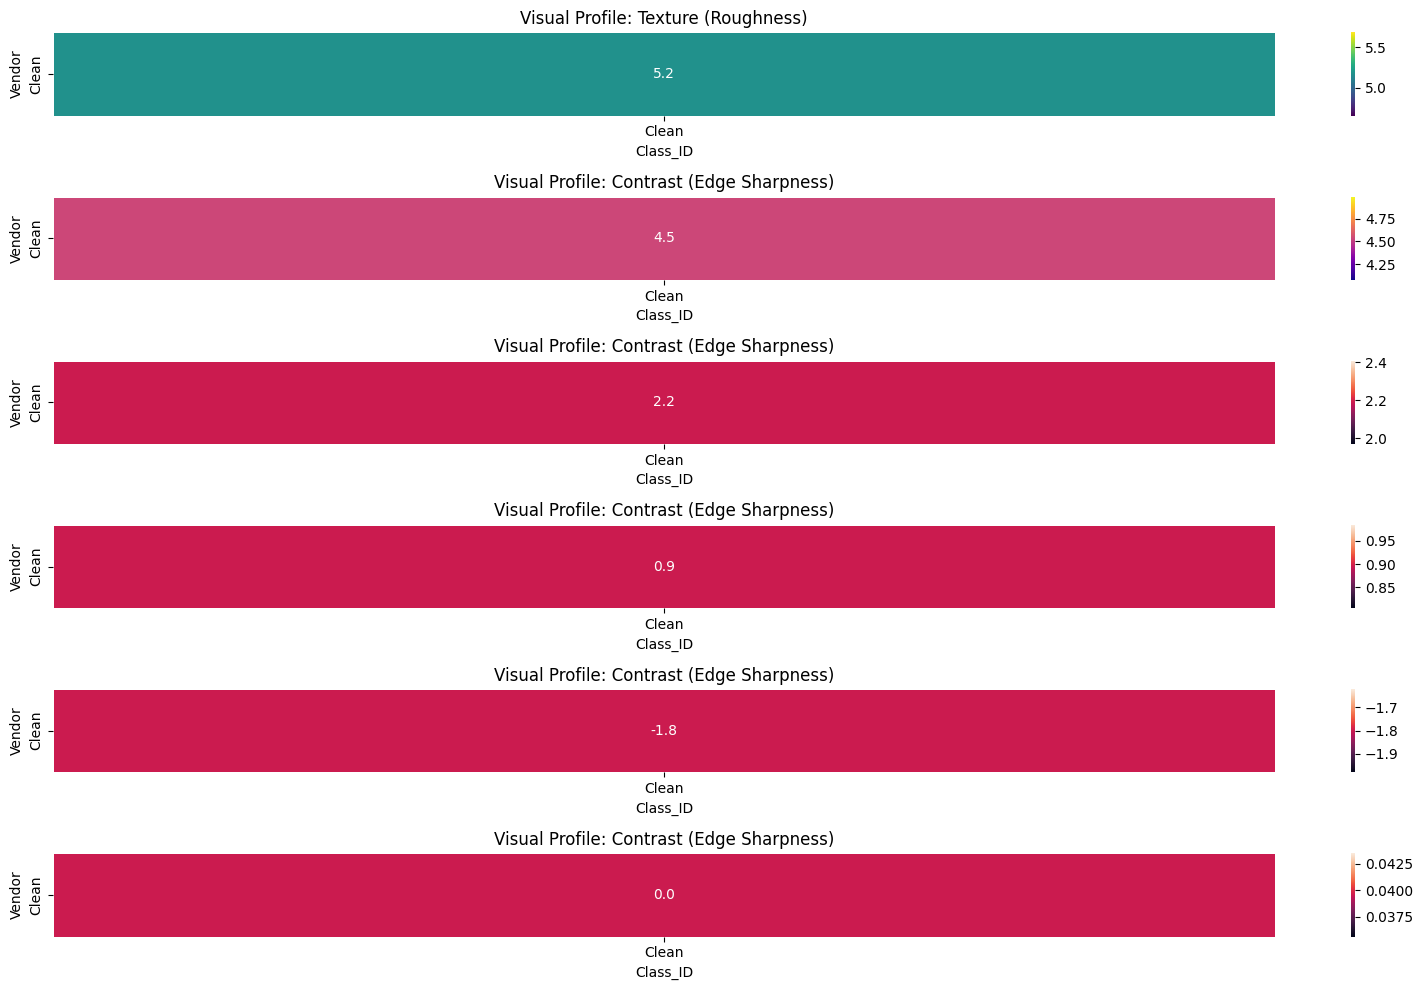

In [ ]:

plt.figure(figsize=(16, 10))

# Plot 1: Texture Heatmap
plt.subplot(6, 1, 1)
sns.heatmap(texture_matrix, annot=True, fmt=".1f", cmap='viridis', linewidths=.5)
plt.title('Visual Profile: Texture (Roughness)')

# Plot 2: Contrast Heatmap
plt.subplot(6, 1, 2)
sns.heatmap(contrast_matrix, annot=True, fmt=".1f", cmap='plasma', linewidths=.5)
plt.title('Visual Profile: Contrast (Edge Sharpness)')

plt.subplot(6, 1, 3)
sns.heatmap(aspect_matrix, annot=True, fmt=".1f", linewidths=.5)
plt.title('Visual Profile: Contrast (Edge Sharpness)')


plt.subplot(6, 1, 4)
sns.heatmap(solidity_matrix, annot=True, fmt=".1f", linewidths=.5)
plt.title('Visual Profile: Contrast (Edge Sharpness)')


plt.subplot(6, 1, 5)
sns.heatmap(skew_matrix, annot=True, fmt=".1f", linewidths=.5)
plt.title('Visual Profile: Contrast (Edge Sharpness)')


plt.subplot(6, 1, 6)
sns.heatmap(edge_dens_matrix, annot=True, fmt=".1f", linewidths=.5)
plt.title('Visual Profile: Contrast (Edge Sharpness)')


plt.tight_layout()
plt.show()

Loading 6972 images...


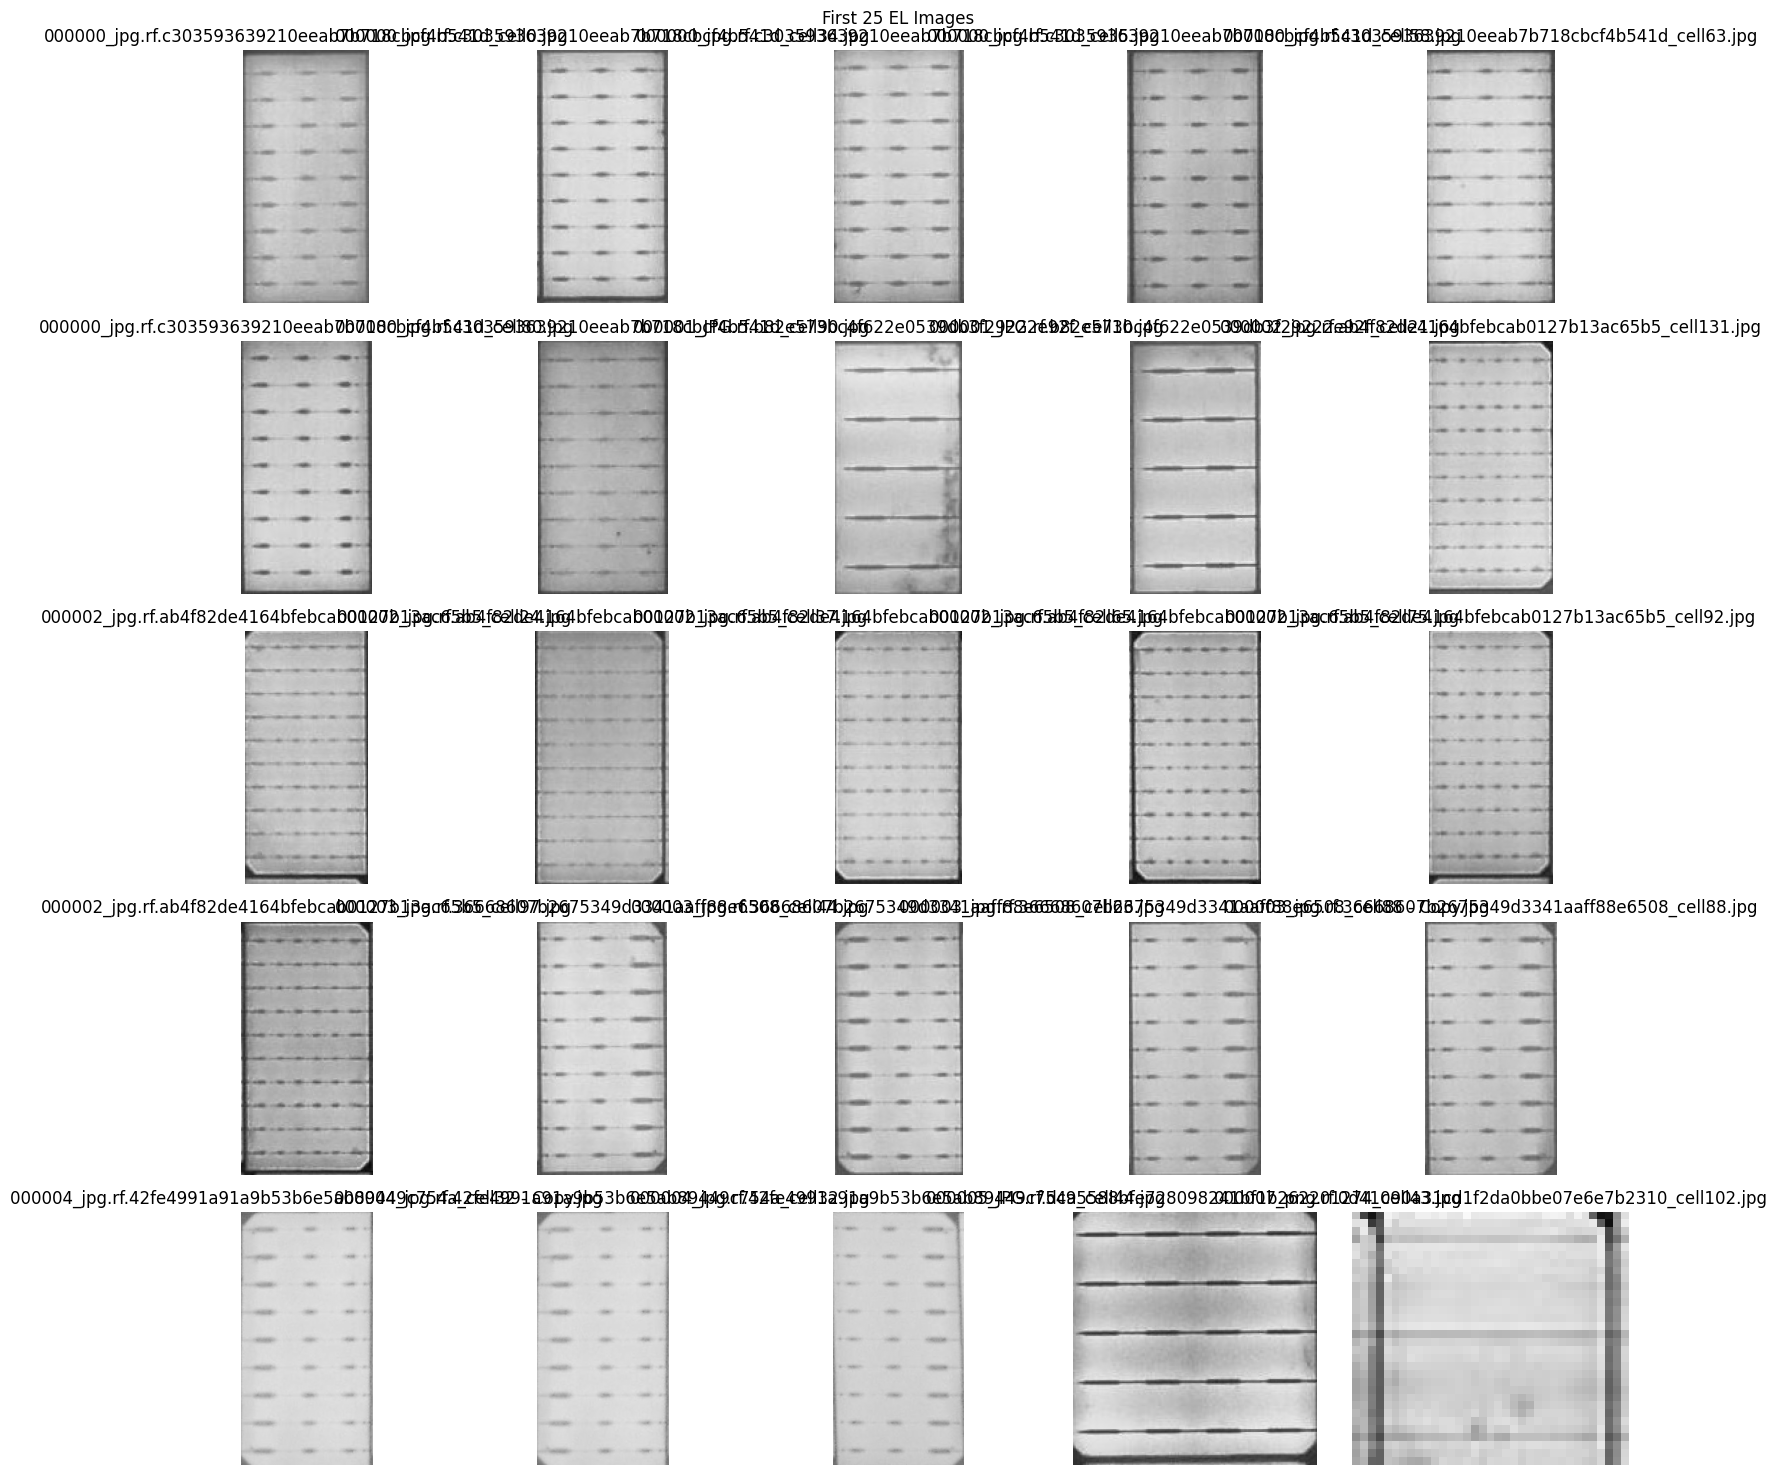

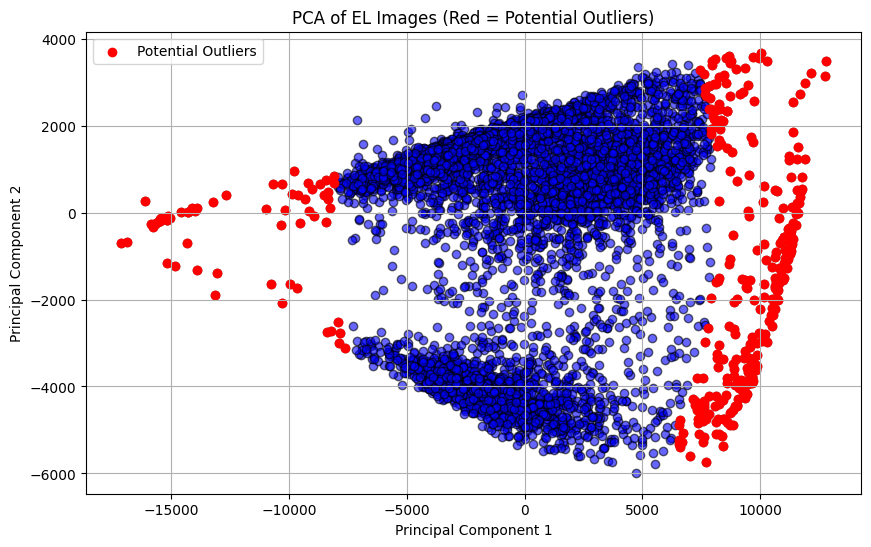


Calculating Top Outliers based on difference from Average image...
Displaying the top 5 most anomalous images based on pixel deviation:


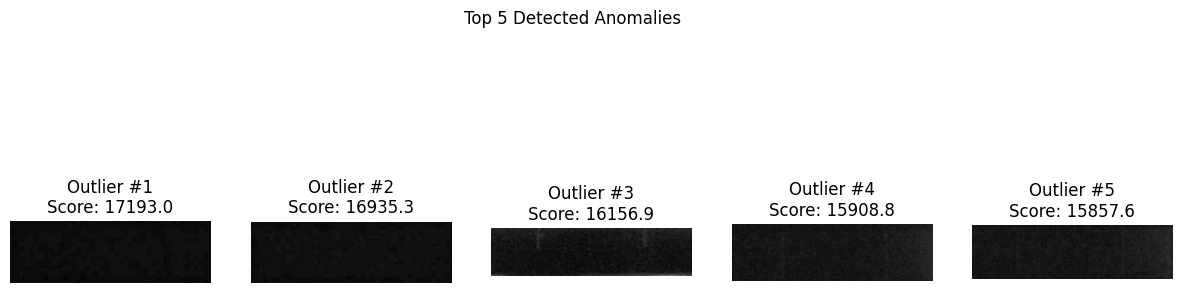

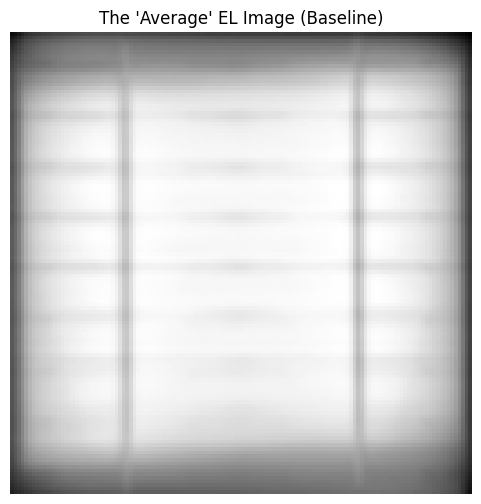

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.decomposition import PCA
from skimage.metrics import structural_similarity as ssim
import glob

# 1. LOAD AND PREPROCESS IMAGES
def load_images(folder_path, size=(128, 128)):
    """
    Load images from a folder, resize them, and convert to grayscale.
    Resizing makes analysis faster; we keep original names for display.
    """
    image_paths = glob.glob(os.path.join(folder_path, '*.*'))
    data = []
    original_images = []
    valid_paths = []
    
    print(f"Loading {len(image_paths)} images...")
    
    for path in image_paths:
        try:
            # Open and convert to grayscale ('L')
            img = Image.open(path).convert('L')
            # Keep a copy for visualization (original size)
            original_images.append(np.array(img))
            # Resize for analysis
            img_resized = img.resize(size)
            data.append(np.array(img_resized).flatten()) # Flatten to 1D vector
            valid_paths.append(path)
        except Exception as e:
            print(f"Error loading {path}: {e}")

    return np.array(data), original_images, valid_paths

# Update this path to your folder containing EL images
# FOLDER_PATH = r'C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\cropped_clean_using_yo8s_1280_p10_rmvd_dircty' # after removing outliers 
FOLDER_PATH = r'C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\healthy_from_mixed_after_yolo8s' 
X_flat, original_imgs, paths = load_images(FOLDER_PATH)

if len(X_flat) == 0:
    print("No images found! Please check the folder path.")
else:
    # ---------------------------------------------------------
    # METHOD 1: GRID VISUALIZATION (Manual Inspection)
    # ---------------------------------------------------------
    def plot_image_grid(images, n_cols=5, title="EL Image Grid"):
        n_rows = int(np.ceil(len(images) / n_cols))
        plt.figure(figsize=(15, n_rows * 3))
        for i, img in enumerate(images):
            plt.subplot(n_rows, n_cols, i + 1)
            # Using 'gray' colormap for EL images
            plt.imshow(img, cmap='gray', vmin=0, vmax=255) 
            plt.title(os.path.basename(paths[i]))
            plt.axis('off')
        plt.suptitle(title)
        plt.tight_layout()
        plt.show()

    # Show first 25 images
    plot_image_grid(original_imgs[:25], title="First 25 EL Images")

    # ---------------------------------------------------------
    # METHOD 2: PCA SCATTER PLOT (Spotting Clusters vs Outliers)
    # ---------------------------------------------------------
    # Reduce dimensions to 2D using Principal Component Analysis
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_flat)

    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, c='blue', edgecolors='k')
    
    # Identify potential outliers (points far from center)
    # We calculate distance from the mean of the PCA components
    distances = np.linalg.norm(X_pca - np.mean(X_pca, axis=0), axis=1)
    threshold = np.percentile(distances, 95) # Top 5% furthest points
    outliers = distances > threshold

    # Highlight outliers in red
    plt.scatter(X_pca[outliers, 0], X_pca[outliers, 1], c='red', label='Potential Outliers')
    
    plt.title("PCA of EL Images (Red = Potential Outliers)")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------------------------------------------------------
    # METHOD 3: VISUALIZE TOP OUTLIERS (Difference from Mean)
    # ---------------------------------------------------------
    print("\nCalculating Top Outliers based on difference from Average image...")
    
    # Calculate the "Mean" (Average) EL image
    mean_img_flat = np.mean(X_flat, axis=0)
    
    # Calculate Euclidean distance between every image and the mean image
    diffs = np.linalg.norm(X_flat - mean_img_flat, axis=1)
    
    # Get indices of the top 5 most different images
    top_outlier_indices = np.argsort(diffs)[-5:][::-1] # Reverse to get highest first
    
    print("Displaying the top 5 most anomalous images based on pixel deviation:")
    
    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(top_outlier_indices):
        plt.subplot(1, 5, i+1)
        plt.imshow(original_imgs[idx], cmap='gray', vmin=0, vmax=255)
        plt.title(f"Outlier #{i+1}\nScore: {diffs[idx]:.1f}")
        plt.axis('off')
        
        # Optional: Draw the mean image next to them for comparison in a separate figure
    plt.suptitle("Top 5 Detected Anomalies")
    plt.show()

    # Display the Average Image (What the AI considers "Normal")
    plt.figure(figsize=(6,6))
    plt.imshow(mean_img_flat.reshape(128, 128), cmap='gray')
    plt.title("The 'Average' EL Image (Baseline)")
    plt.axis('off')
    plt.show()

Original Dataset Size: 6972
Clean Dataset Size:     6762 (Kept)
Removed Outliers:       210 (Discarded)


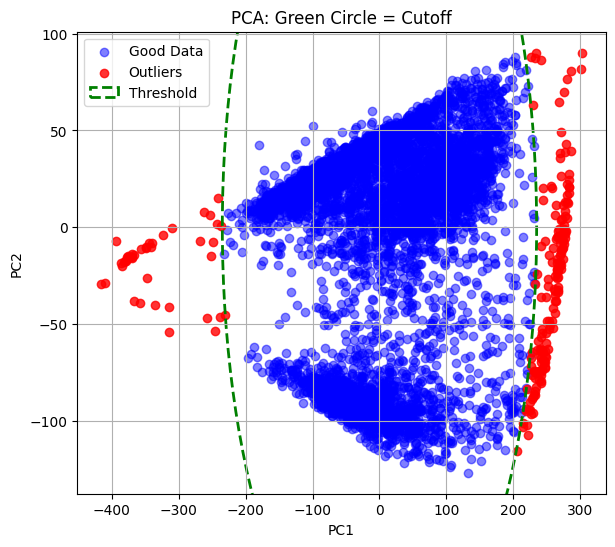

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Assuming you already have X_flat (flattened images) loaded from the previous step
# ---------------------------------------------------------

# 1. Standardize data before PCA (Important for correct distance calculation)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)

# 2. Run PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3. Calculate Distances from the Center (The Refinement Logic)
# The center is essentially (0,0) because PCA centers the data
centroid = np.mean(X_pca, axis=0)

# Calculate Euclidean distance for every point: sqrt((x-cx)^2 + (y-cy)^2)
distances = np.linalg.norm(X_pca - centroid, axis=1)

# 4. Define a Threshold
# Option A: Remove top 5% furthest points
threshold = np.percentile(distances, 97)

# Option B: Remove anything > 3 Standard Deviations away
# threshold = np.mean(distances) + 3 * np.std(distances)

# Identify who is an "Inlier" (Good data) and who is an "Outlier" (Bad data)
is_inlier = distances <= threshold
is_outlier = distances > threshold

# ---------------------------------------------------------
# 5. Apply the Filter to your Original Data
# ---------------------------------------------------------

# Create your new, refined datasets
X_clean = X_flat[is_inlier]
paths_clean = np.array(paths)[is_inlier]

# See what we are throwing away
X_dirty = X_flat[is_outlier]
paths_dirty = np.array(paths)[is_outlier]

print(f"Original Dataset Size: {len(X_flat)}")
print(f"Clean Dataset Size:     {len(X_clean)} (Kept)")
print(f"Removed Outliers:       {len(X_dirty)} (Discarded)")

# ---------------------------------------------------------
# 6. Visual Verification (Before and After)
# ---------------------------------------------------------

plt.figure(figsize=(15, 6))

# PLOT 1: The PCA Scatter Plot with the Threshold Circle
plt.subplot(1, 2, 1)
plt.scatter(X_pca[is_inlier, 0], X_pca[is_inlier, 1], c='blue', label='Good Data', alpha=0.5)
plt.scatter(X_pca[is_outlier, 0], X_pca[is_outlier, 1], c='red', label='Outliers', alpha=0.8)

# Draw the threshold circle
circle = plt.Circle((0, 0), threshold, color='green', fill=False, linestyle='--', linewidth=2, label='Threshold')
plt.gca().add_artist(circle)

plt.title("PCA: Green Circle = Cutoff")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)


# ---------------------------------------------------------
# 7. Save the Clean List (Optional)
# ---------------------------------------------------------
with open("clean_image_list_mixed.txt", "w") as f:
    for p in paths_clean:
        f.write(p + "\n")

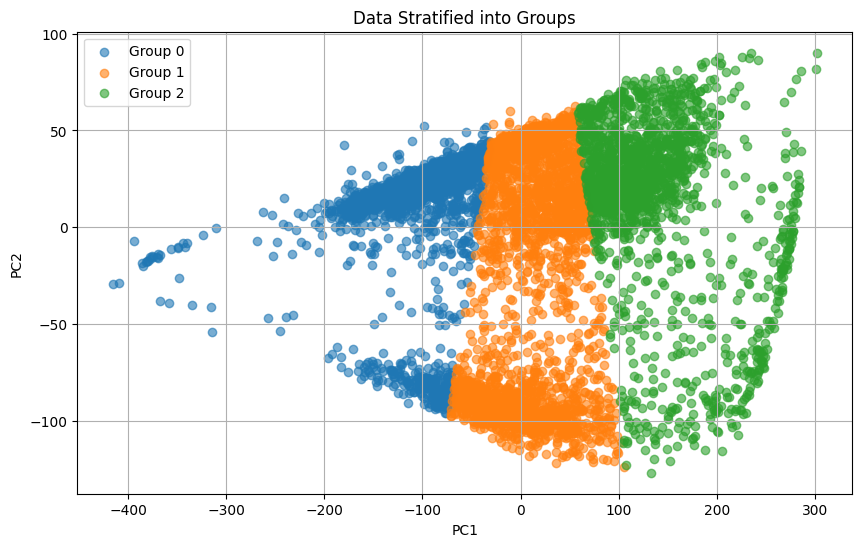

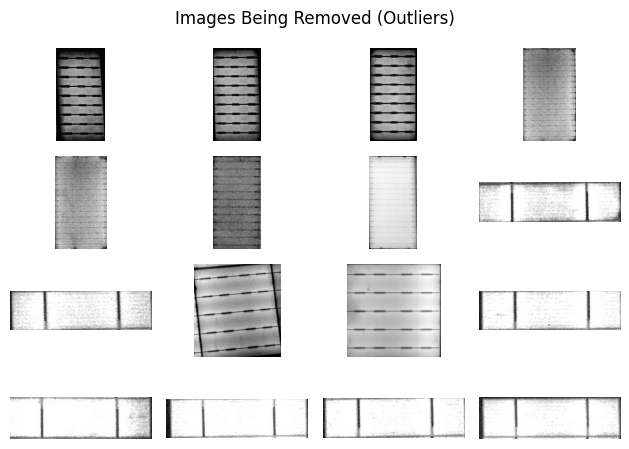

In [ ]:
# PLOT 2: Visualize the images being removed
# plt.subplot(1, 2, 2)
# Show up to 16 of the removed outliers
n_show = min(len(paths_dirty), 16)
for i in range(n_show):
    plt.subplot(4, 4, i+1)
    # Load image to display (assuming 'original_imgs' is still in memory)
    # Note: You need the index from the original array, not the subset
    outlier_idx = np.where(is_outlier)[0][i] 
    plt.imshow(original_imgs[outlier_idx],   cmap='gray')
    # print(paths_dirty[outlier_idx])
    plt.axis('off')

plt.suptitle("Images Being Removed (Outliers)")
plt.tight_layout()
plt.show()

In [ ]:
import shutil   

for img in paths_dirty:

    shutil.move(img, r"C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\healthy_from_mixed_after_yolo8s_dirty\\"+os.path.basename(img))

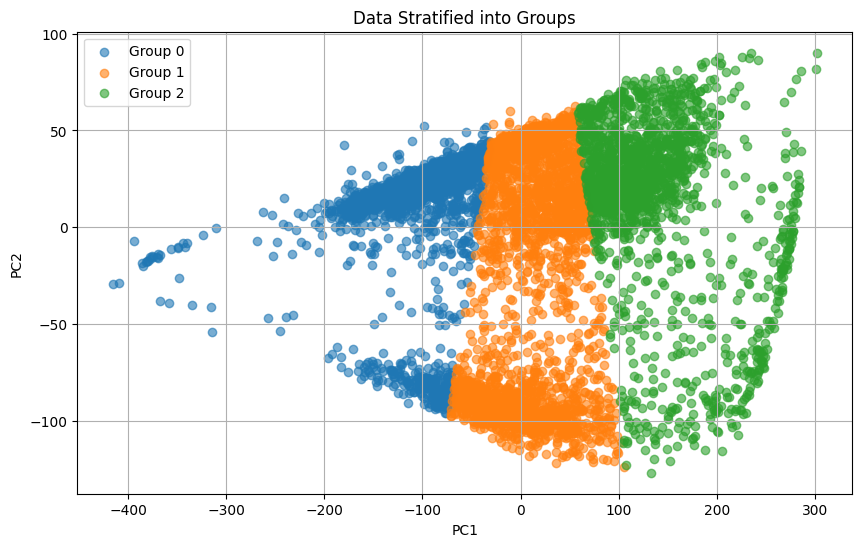

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Assuming X_pca is already calculated from the previous steps

# 1. Find Clusters (Groups)
# We ask the algorithm to find, say, 2 or 3 distinct groups based on the PCA visual
n_clusters = 3 # Change this based on how many "blobs" you see in your plot
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(X_pca)

# 2. Visualize the Groups
plt.figure(figsize=(10, 6))
for i in range(n_clusters):
    # Plot points belonging to cluster i
    plt.scatter(X_pca[clusters == i, 0], X_pca[clusters == i, 1], label=f'Group {i}', alpha=0.6)

plt.title("Data Stratified into Groups")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)
plt.show()

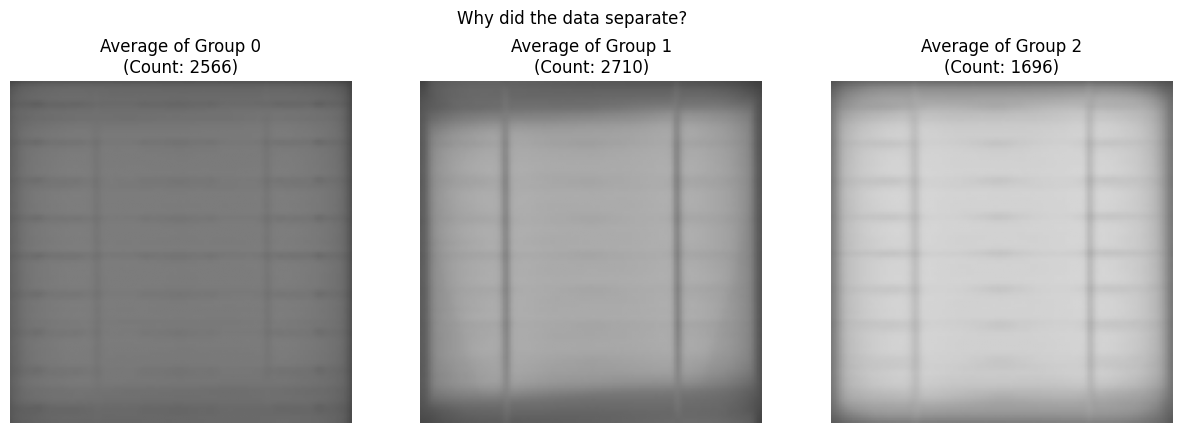

In [ ]:
# 3. Visualize the "Mean" of each Group
# This shows what the model thinks is the "Standard" for that group

plt.figure(figsize=(15, 5))

for i in range(n_clusters):
    # Get all images belonging to this cluster
    indices = np.where(clusters == i)[0]
    group_images = X_flat[indices]
    
    # Calculate the mean image for this group
    mean_img = np.mean(group_images, axis=0).reshape(128, 128)
    
    plt.subplot(1, n_clusters, i + 1)
    plt.imshow(mean_img, cmap='gray', vmin=0, vmax=255)
    plt.title(f"Average of Group {i}\n(Count: {len(indices)})")
    plt.axis('off')

plt.suptitle("Why did the data separate?")
plt.show()

In [ ]:
clean_indices = []
outlier_indices = []

for i in range(n_clusters):
    # Get data for just this group
    group_mask = (clusters == i)
    group_pca = X_pca[group_mask]
    group_indices = np.where(group_mask)[0] # The original indices in the dataset
    
    if len(group_pca) == 0: continue
    
    # Calculate Centroid of THIS group only
    centroid = np.mean(group_pca, axis=0)
    
    # Calculate distances within this group
    distances = np.linalg.norm(group_pca - centroid, axis=1)
    
    # Threshold: Remove top 5% worst within THIS group
    threshold = np.percentile(distances, 95)
    
    is_clean = distances <= threshold
    
    # Map back to original indices
    # The boolean array 'is_clean' matches the order of 'group_indices'
    current_clean_indices = group_indices[is_clean]
    current_outlier_indices = group_indices[~is_clean]
    
    clean_indices.extend(current_clean_indices)
    outlier_indices.extend(current_outlier_indices)
    
    print(f"Group {i}: Kept {len(current_clean_indices)}, Removed {len(current_outlier_indices)}")

print(f"\nTotal Clean Images: {len(clean_indices)}")

Group 0: Kept 2437, Removed 129
Group 1: Kept 2574, Removed 136
Group 2: Kept 1611, Removed 85

Total Clean Images: 6622


In [ ]:
outlier_indices

[105,
 113,
 365,
 366,
 367,
 825,
 826,
 827,
 853,
 854,
 1485,
 1623,
 2289,
 4025,
 4046,
 4119,
 4139,
 5154,
 5155,
 5167,
 5170,
 5172,
 5197,
 5209,
 5210,
 5211,
 5213,
 5222,
 5223,
 5226,
 5227,
 5230,
 5237,
 5238,
 5241,
 5242,
 5243,
 5244,
 5245,
 5257,
 5271,
 5290,
 5336,
 5342,
 5344,
 5350,
 5367,
 5372,
 5373,
 5386,
 5387,
 5399,
 5403,
 5458,
 5490,
 5577,
 5590,
 5598,
 5605,
 5614,
 5616,
 5617,
 5620,
 5653,
 5716,
 5735,
 5772,
 5779,
 5780,
 5838,
 6078,
 6112,
 6118,
 6169,
 6171,
 6175,
 6177,
 6179,
 6180,
 6185,
 6186,
 6187,
 6188,
 6189,
 6191,
 6226,
 6229,
 6234,
 6257,
 6330,
 6358,
 6380,
 6397,
 6406,
 6421,
 6427,
 6430,
 6432,
 6453,
 6498,
 6571,
 6573,
 6578,
 6584,
 6595,
 6604,
 6617,
 6625,
 6649,
 6658,
 6685,
 6807,
 6816,
 6817,
 6829,
 6832,
 6833,
 6835,
 6852,
 6855,
 6858,
 6884,
 6891,
 6893,
 6900,
 6906,
 6907,
 6908,
 6910,
 5329,
 5330,
 5347,
 5370,
 5376,
 5393,
 5397,
 5400,
 5408,
 5410,
 5413,
 5414,
 5418,
 5425,
 5429,
 5

In [ ]:
from ultralytics import YOLO
from pathlib import Path

model_path = r"runs\detect\train97\weights\best.pt"
input_dir = r"C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\healthy_from_mixed_after_yolo8s_rmvd_dirty"
output_dir = r"C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\healthy_removed__dirty_by_yolo2"

conf_thresh = 0.7  # adjust as needed

os.makedirs(output_dir, exist_ok=True)

model = YOLO(model_path)

for img_path in Path(input_dir).glob("*.*"):
    results = model(str(img_path), conf=conf_thresh, verbose=False, imgsz=320)

    # results is a list (one element per image)
    r = results[0]

    # If at least one detection survives confidence threshold
    if r.boxes is not None and len(r.boxes) > 0:
        shutil.copy(
            img_path,
            os.path.join(output_dir, img_path.name)
        )

In [ ]:
dirty_yolo = os.listdir(r"C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\healthy_removed__dirty_by_yolo2")

for img in dirty_yolo:

    shutil.move(
            r"C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\healthy_from_mixed_after_yolo8s_rmvd_dirty\\"+img,
            r"C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\healthy_removed__dirty_by_yolo2\\"+img
            
        )

In [ ]:
import torch
from torchvision import models, transforms
from PIL import Image
import os
import numpy as np

model = models.resnet18(pretrained=True)
model.fc = torch.nn.Identity()
model.eval().cuda()

tfm = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485], std=[0.229])
])

features = []
paths = []

for img in os.listdir(r"C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\healthy_from_mixed_after_yolo8s_rmvd_dirty"):
    im = Image.open(fr"C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\healthy_from_mixed_after_yolo8s_rmvd_dirty/{img}").convert("L")
    x = tfm(im).unsqueeze(0).cuda()
    with torch.no_grad():
        f = model(x).cpu().numpy().squeeze()
    features.append(f)
    paths.append(img)

features = np.array(features)

from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=5).fit(features)
dists, _ = nbrs.kneighbors(features)

scores = dists.mean(axis=1)

thr = np.percentile(scores, 97)
outliers = scores > thr

c:\Users\Rowan\Documents\Rowan\Yolo_test\final_env_yolo\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Rowan\Documents\Rowan\Yolo_test\final_env_yolo\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
images = os.listdir(r"C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\healthy_from_mixed_after_yolo8s_rmvd_dirty")

In [ ]:
np.where(group_mask)[0]

array([   0,    1,    2, ..., 6969, 6970, 6971], dtype=int64)

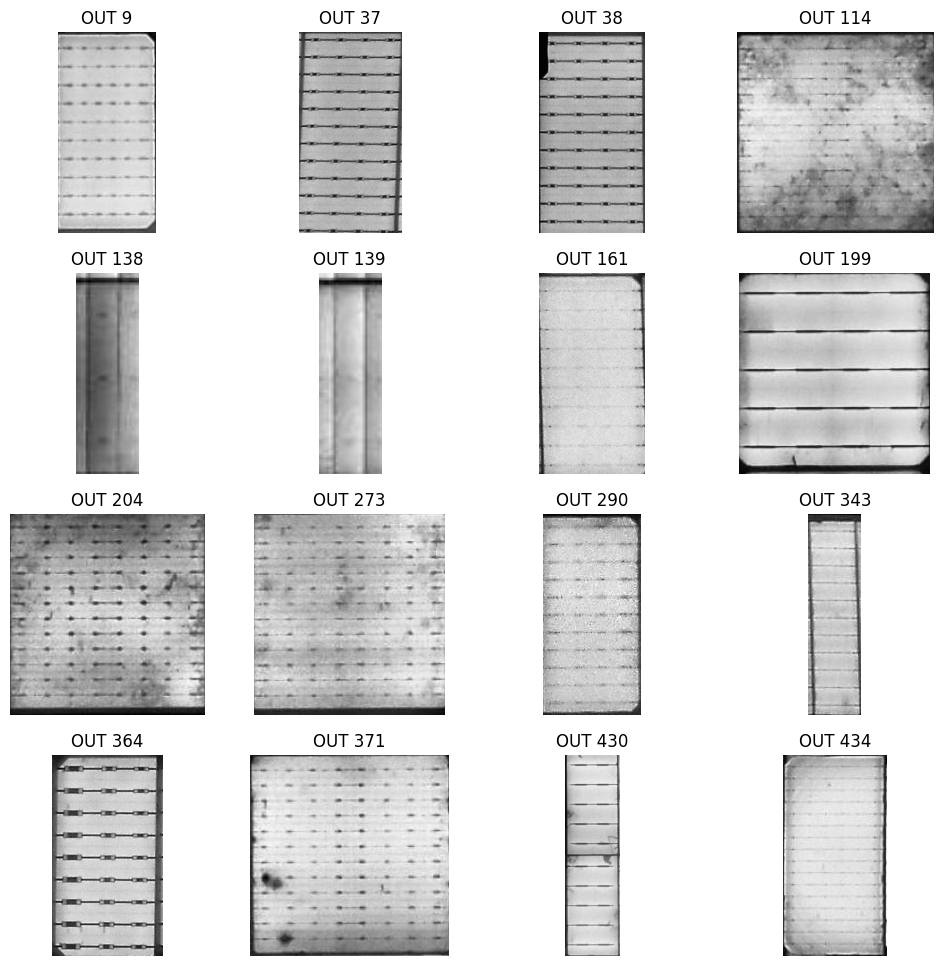

In [ ]:
import matplotlib.pyplot as plt
import cv2

out_idx = np.where(outliers)[0][:16]

plt.figure(figsize=(12,12))
for i, idx in enumerate(out_idx):
    img = cv2.imread(fr"C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\healthy_from_mixed_after_yolo8s_rmvd_dirty/{paths[idx]}", 0)
    plt.subplot(4,4,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"OUT {idx}")
    plt.axis('off')
plt.show()

In [ ]:
out_idx = np.where(outliers)[0]

for i, idx in enumerate(out_idx):
    img_path = fr"C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\healthy_from_mixed_after_yolo8s_rmvd_dirty/{paths[idx]}"
    
    shutil.move(
                img_path,
                r"C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\healthy_rm_gpt\\"+paths[idx]
                
            )

In [31]:
import os
import cv2
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from tqdm import tqdm

DATA_DIR = r"C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\healthy_from_mixed_after_yolo8s_rmvd_dirty/"   # CHANGE
DATA_DIR = r"C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\cropped_clean_using_yo8s_1280_p10_rmvd_dirty/"   # CHANGE
DATA_DIR = r"C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster\combined"   # CHANGE
IMG_SIZE = 224
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
model.fc = torch.nn.Identity()
model.eval().to(DEVICE)

transform = T.Compose([
    T.ToTensor(),
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])



features = []
paths = []

for f in tqdm(os.listdir(DATA_DIR)):
    if not f.lower().endswith((".png", ".jpg", ".jpeg")):
        continue
    p = os.path.join(DATA_DIR, f)
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    x = transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        feat = model(x).cpu().numpy().squeeze()

    features.append(feat)
    paths.append(p)

features = np.stack(features)
print("Feature shape:", features.shape)

100%|██████████| 1433/1433 [00:08<00:00, 162.75it/s]

Feature shape: (1433, 2048)


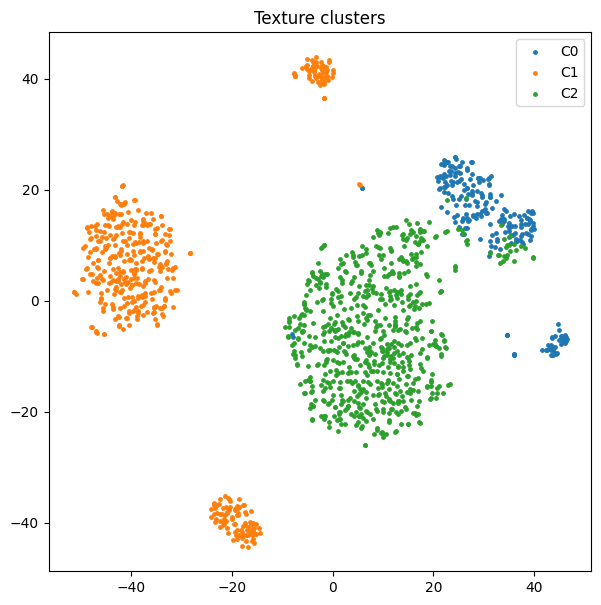

In [35]:
from sklearn.cluster import KMeans

k = 3  # start with 2–4
kmeans = KMeans(n_clusters=k, random_state=0)
labels = kmeans.fit_predict(features)

plt.figure(figsize=(7,7))
for i in range(k):
    idx = labels == i
    plt.scatter(emb[idx,0], emb[idx,1], s=6, label=f"C{i}")
plt.legend()
plt.title("Texture clusters")
plt.show()

In [36]:
CLUSTER_DIR = r"C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_combined_cluster"
os.makedirs(CLUSTER_DIR, exist_ok=True)

for i in range(k):
    os.makedirs(os.path.join(CLUSTER_DIR, f"cluster_{i}"), exist_ok=True)

import shutil

for i, path in enumerate(paths):
    cluster_idx = labels[i]
    dst_folder = os.path.join(CLUSTER_DIR, f"cluster_{cluster_idx}")
    shutil.copy(path, dst_folder)

from sklearn.metrics import pairwise_distances

# Distance to cluster center
dist_to_center = np.linalg.norm(features - kmeans.cluster_centers_[labels], axis=1)
threshold = np.percentile(dist_to_center, 95)  # top 5% farthest
outlier_idx = np.where(dist_to_center > threshold)[0]

print("Potential outliers:", len(outlier_idx))
for i in outlier_idx[:10]:
    print(paths[i])

Potential outliers: 72
C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster\combined\000043_jpg.rf.66ef7afc9fe4a50acc1fa1d5e22e110b_cell28.jpg
C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster\combined\000290_JPG.rf.49ec0fcd6c9f1c5f5744589ab1369b50_cell38.jpg
C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster\combined\000384_jpg.rf.17c948d819182bf6964fc8d72e051591_cell48.jpg
C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster\combined\000384_jpg.rf.17c948d819182bf6964fc8d72e051591_cell59.jpg
C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster\combined\000385_jpg.rf.a7cd14e3550ce43fbcd66e6776650a37_cell27.jpg
C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster\combined\000395_jpg.rf.15c9bbf3dd428e877b70424af4140ec6_cell26.jpg
C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster\combined\000438_jpg.rf.b67622997984d13115731f08008da9c4_cell0.jpg
C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster\combined\0004

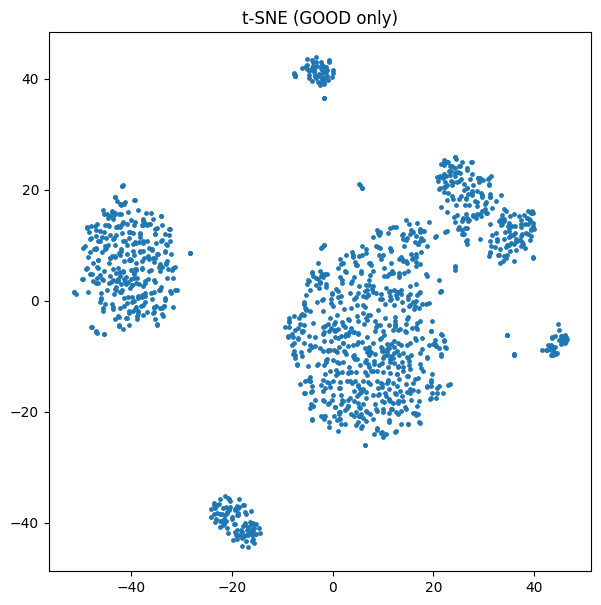

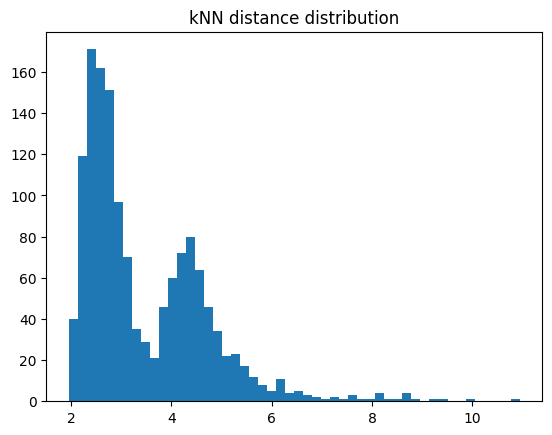

Outliers: 43
C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster\combined\000235_JPG.rf.6de32e4e291c70c5fce9a08c1131a654_cell38.jpg
C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster\combined\000290_JPG.rf.49ec0fcd6c9f1c5f5744589ab1369b50_cell38.jpg
C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster\combined\000331_jpg.rf.969df2ad73272cbe5cf64bb3312c0a1b_cell52.jpg
C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster\combined\000394_jpg.rf.aaaa81726b3efa4cf11b6b77ff87069e_cell120.jpg
C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster\combined\000438_jpg.rf.b67622997984d13115731f08008da9c4_cell2.jpg
C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster\combined\000515_jpg.rf.2e353ac5af7f9ea2fc5f684185e252f7_cell0.jpg
C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster\combined\000525_JPG.rf.70905166a679c38298809681a10d50f1_cell37.jpg
C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster\combined\000531_jpg.rf.

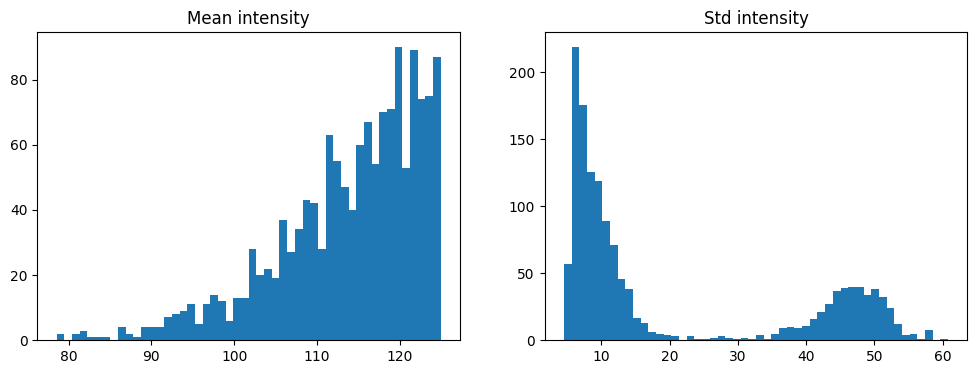

In [32]:
tsne = TSNE(n_components=2, perplexity=30, random_state=0)
emb = tsne.fit_transform(features)

plt.figure(figsize=(7,7))
plt.scatter(emb[:,0], emb[:,1], s=6)
plt.title("t-SNE (GOOD only)")
plt.show()


knn = NearestNeighbors(n_neighbors=6)
knn.fit(features)

dists, _ = knn.kneighbors(features)
mean_knn_dist = dists[:,1:].mean(axis=1)


plt.hist(mean_knn_dist, bins=50)
plt.title("kNN distance distribution")
plt.show()


thr = np.percentile(mean_knn_dist, 97)
outlier_idx = np.where(mean_knn_dist > thr)[0]

print("Outliers:", len(outlier_idx))


for i in outlier_idx[:10]:
    print(paths[i])


means, stds = [], []

for p in paths:
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    means.append(img.mean())
    stds.append(img.std())

means = np.array(means)
stds = np.array(stds)


plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(means, bins=50); plt.title("Mean intensity")
plt.subplot(1,2,2)
plt.hist(stds, bins=50); plt.title("Std intensity")
plt.show()

In [7]:
import shutil

C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster\combined\000057_jpg.rf.bd8ef4626426e97b7d70ba36fff59cd8_cell28.jpg
C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster\combined\000493_png.rf.61413b678249a0766b018ff89e065f00_cell77.jpg
C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster\combined\000515_jpg.rf.2e353ac5af7f9ea2fc5f684185e252f7_cell36.jpg
C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster\combined\000521_png.rf.877fd0ca5e23554376fe3b7c9129b05a_cell19.jpg
C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster\combined\000547_png.rf.c8a7b008342e31a00ff134dde160e947_cell30.jpg
C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster\combined\000599_png.rf.fa6d6ba0bfdefc828eca60c65c4c65de_cell25.jpg
C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster\combined\000599_png.rf.fa6d6ba0bfdefc828eca60c65c4c65de_cell95.jpg
C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster\combined\000726_png.rf.6e46ec8909f5

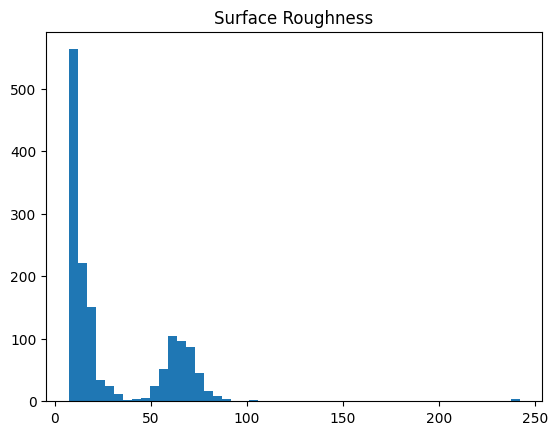

In [26]:
def surface_roughness(img):
    gx = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=3)
    grad = np.sqrt(gx**2 + gy**2)
    return grad.mean()

roughness = []

for p in paths:
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if surface_roughness(img) > 100:
        print(p)
    roughness.append(surface_roughness(img))

roughness = np.array(roughness)

print("Mean roughness:", roughness.mean())
print("Var roughness :", roughness.var())

plt.hist(roughness, bins=50)
plt.title("Surface Roughness")
plt.show()


In [ ]:
C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster\combined\000057_jpg.rf.bd8ef4626426e97b7d70ba36fff59cd8_cell28.jpg
C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster\combined\000493_png.rf.61413b678249a0766b018ff89e065f00_cell77.jpg
C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster\combined\000515_jpg.rf.2e353ac5af7f9ea2fc5f684185e252f7_cell36.jpg
C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster\combined\000521_png.rf.877fd0ca5e23554376fe3b7c9129b05a_cell19.jpg
C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster\combined\000547_png.rf.c8a7b008342e31a00ff134dde160e947_cell30.jpg
C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster\combined\000599_png.rf.fa6d6ba0bfdefc828eca60c65c4c65de_cell25.jpg
C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster\combined\000599_png.rf.fa6d6ba0bfdefc828eca60c65c4c65de_cell95.jpg
C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster\combined\000726_png.rf.6e46ec8909f5ba86212d5af7228526b9_cell13.jpg
Mean roughness: 30.574722

In [ ]:

CLEAN_PATH = r"C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\healthy_from_mixed_after_yolo8s_rmvd_dirty_further_cleaned"
os.makedirs(CLEAN_PATH, exist_ok=True)

keep_idx = np.where(mean_knn_dist <= thr)[0]

for i in keep_idx:
    fname = os.path.basename(paths[i])
    os.system(f"cp '{paths[i]}' '{CLEAN_PATH}/{fname}'")

print("Clean images:", len(keep_idx))

if roughness.var() < 20 and len(outlier_idx)/len(paths) < 0.05:
    print("✅ Data ready for EfficientAD / PatchCore")
else:
    print("⚠️ Split domains or clean more")

Clean images: 5949
⚠️ Split domains or clean more


100%|██████████| 1877/1877 [00:07<00:00, 260.75it/s]


Feature shape: (1877, 2048)


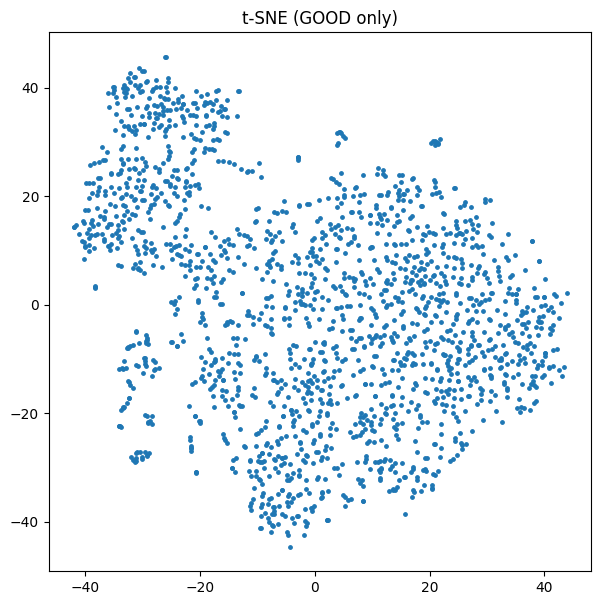

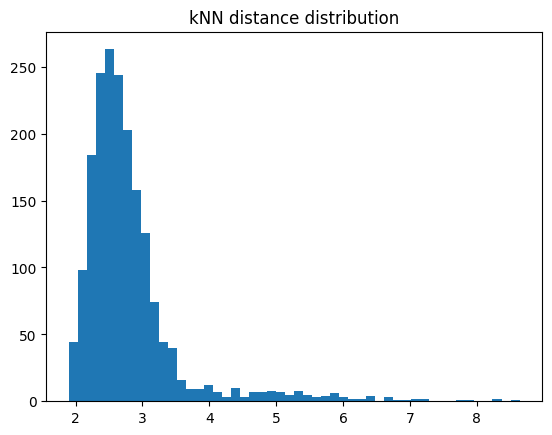

Outliers: 38


100%|██████████| 1044/1044 [00:04<00:00, 258.12it/s]


Feature shape: (1044, 2048)


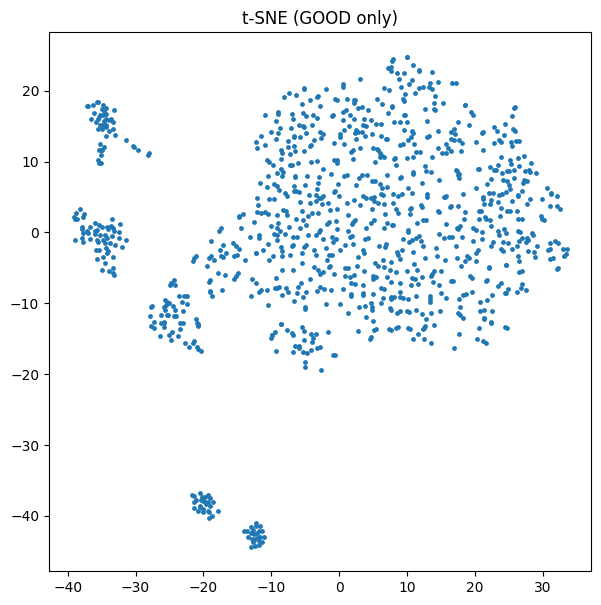

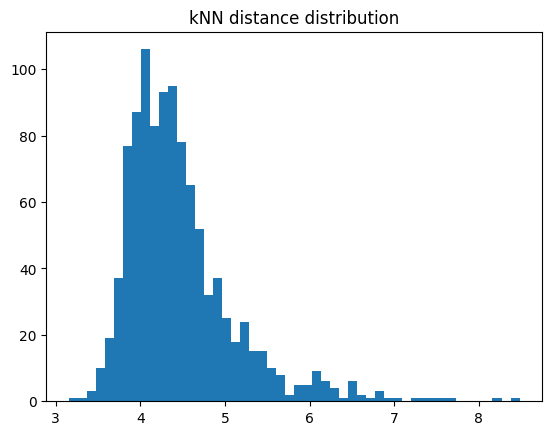

Outliers: 21


100%|██████████| 240/240 [00:00<00:00, 279.83it/s]


Feature shape: (240, 2048)


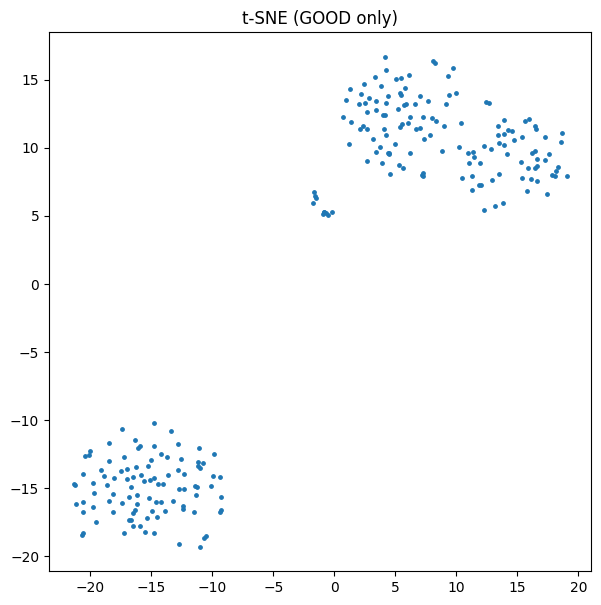

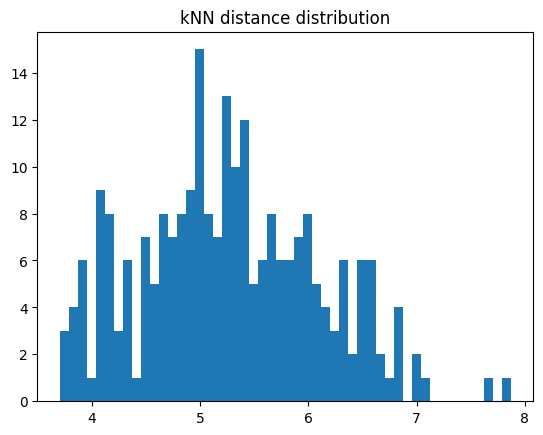

Outliers: 5


100%|██████████| 476/476 [00:01<00:00, 254.39it/s]


Feature shape: (476, 2048)


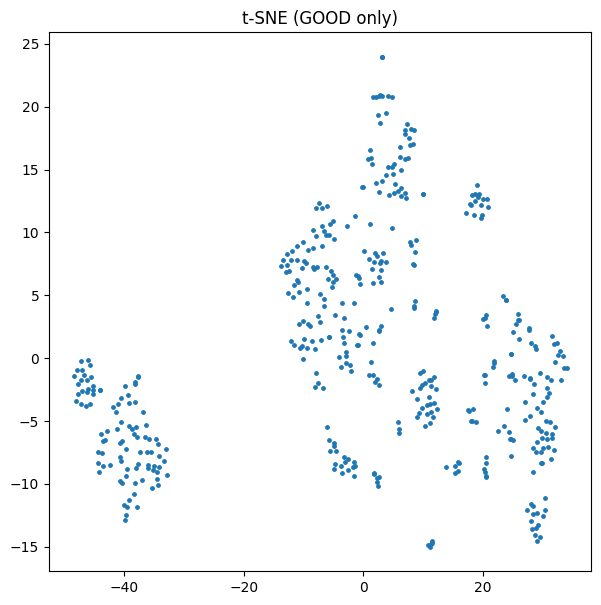

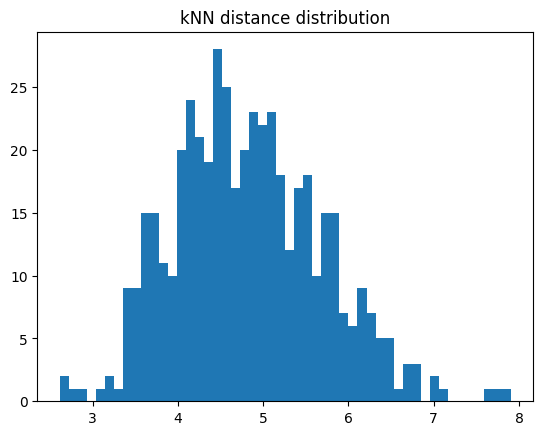

Outliers: 10


100%|██████████| 561/561 [00:02<00:00, 245.87it/s]


Feature shape: (561, 2048)


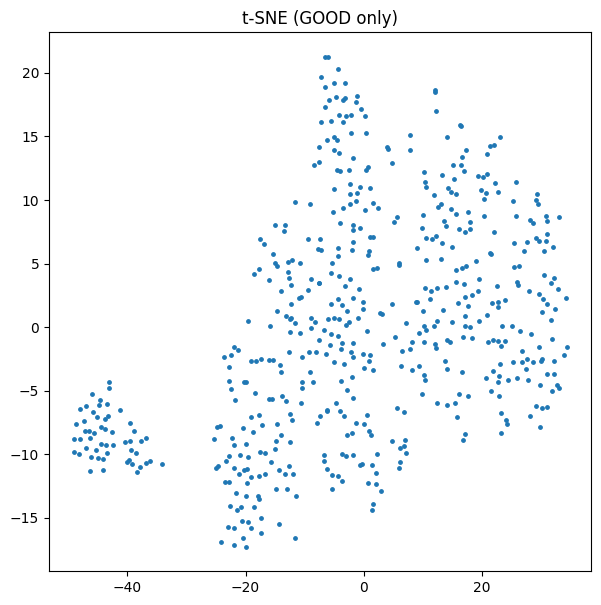

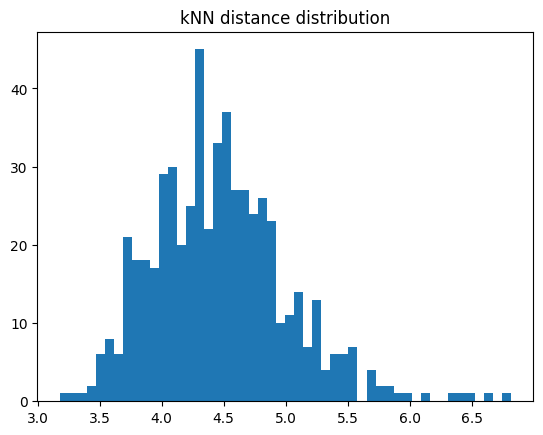

Outliers: 12


100%|██████████| 832/832 [00:03<00:00, 273.92it/s]


Feature shape: (832, 2048)


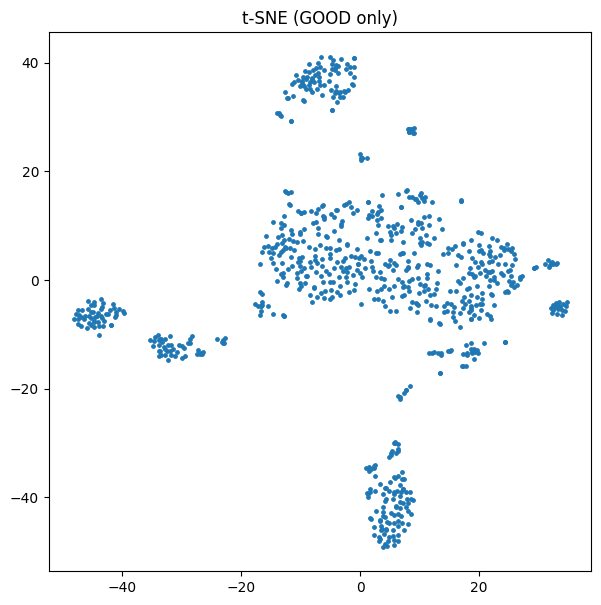

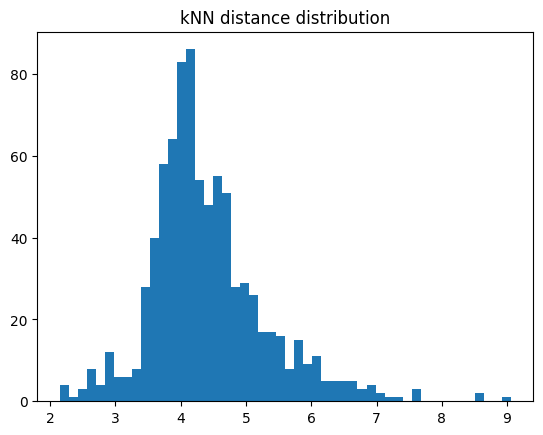

Outliers: 17


100%|██████████| 558/558 [00:02<00:00, 272.93it/s]


Feature shape: (558, 2048)


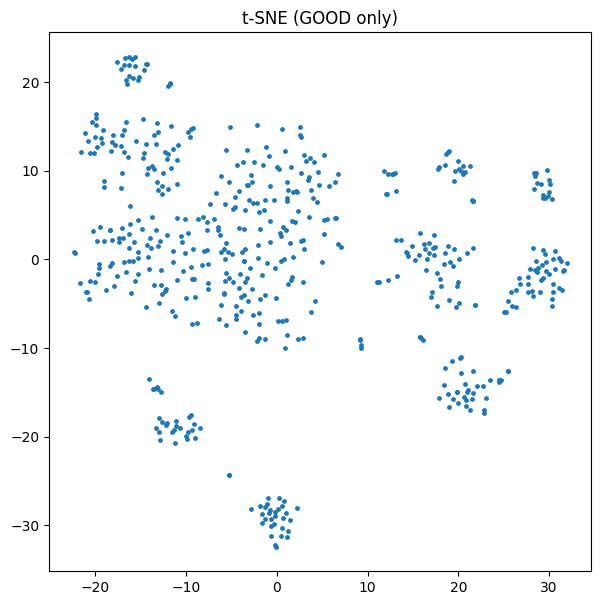

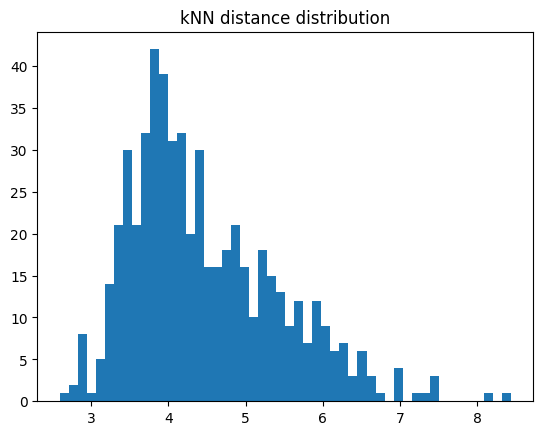

Outliers: 12


In [ ]:
CLUSTER_DIR = r"C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster"

for i in range(7):

    DATA_DIR = os.path.join(CLUSTER_DIR, f"cluster_{i}")
    features = []
    paths = []

    for f in tqdm(os.listdir(DATA_DIR)):
        if not f.lower().endswith((".png", ".jpg", ".jpeg")):
            continue
        p = os.path.join(DATA_DIR, f)
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

        x = transform(img).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            feat = model(x).cpu().numpy().squeeze()

        features.append(feat)
        paths.append(p)

    features = np.stack(features)
    print("Feature shape:", features.shape)
    
    tsne = TSNE(n_components=2, perplexity=30, random_state=0)
    emb = tsne.fit_transform(features)

    plt.figure(figsize=(7,7))
    plt.scatter(emb[:,0], emb[:,1], s=6)
    plt.title("t-SNE (GOOD only)")
    plt.show()


    knn = NearestNeighbors(n_neighbors=6)
    knn.fit(features)

    dists, _ = knn.kneighbors(features)
    mean_knn_dist = dists[:,1:].mean(axis=1)


    plt.hist(mean_knn_dist, bins=50)
    plt.title("kNN distance distribution")
    plt.show()


    thr = np.percentile(mean_knn_dist, 98)
    outlier_idx = np.where(mean_knn_dist > thr)[0]

    print("Outliers:", len(outlier_idx))


    # for i in outlier_idx[:10]:
    #     print(paths[i])

    for j in outlier_idx:
        shutil.move(
                paths[j],
                r"C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster\outliers\\c"+str(i)+"\\"+os.path.basename(paths[j])
            )

    continue
    means, stds = [], []

    for p in paths:
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        means.append(img.mean())
        stds.append(img.std())

    means = np.array(means)
    stds = np.array(stds)


    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.hist(means, bins=50); plt.title("Mean intensity")
    plt.subplot(1,2,2)
    plt.hist(stds, bins=50); plt.title("Std intensity")
    plt.show()

Loading images...
Loaded 1433 images.
Applying CLAHE and Normalization...
Filtering outliers based on intensity...
Stats: Mean Intensity=0.53, Std=0.03
Removing 9 outliers (Too dark/bright).
Generating t-SNE plots (this may take a moment)...


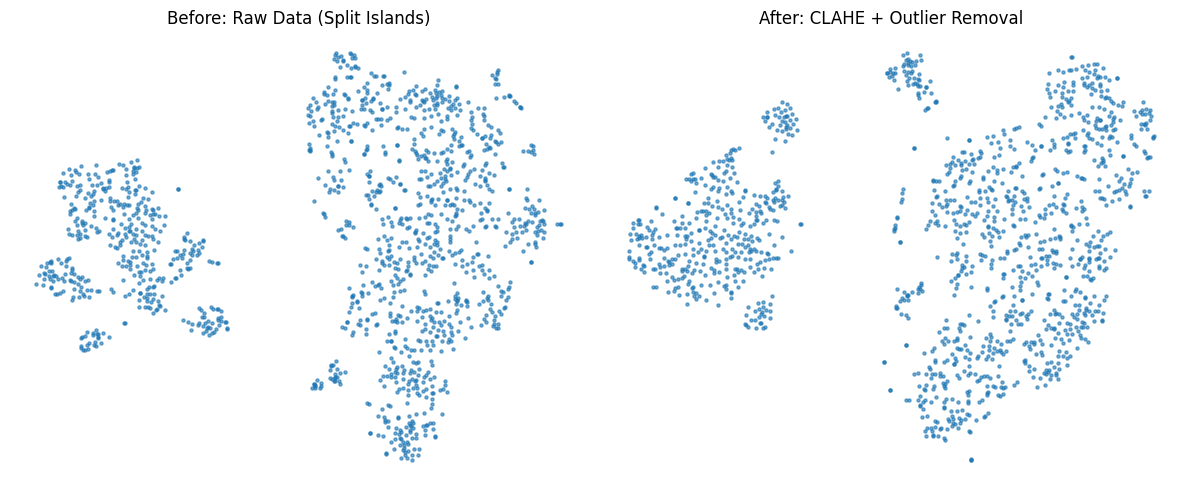

Final dataset size for training: 1424 images.


In [ ]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_PATH = r"C:\Users\Rowan\Documents\Rowan\Yolo_test\anomaly\tsne_cluster\combined"  # i WILL RUN THIS ON THE WHOLE DATASET AFTER CLEANING MNUALL AND MERGING CLUSTERS
IMG_SIZE = (224, 224)              # Resize for speed/consistency

# ==========================================
# 2. PREPROCESSING FUNCTIONS
# ==========================================

def load_images(path):
    """Loads images and converts to grayscale."""
    images = []
    filenames = []
    valid_extensions = {".png", ".jpg", ".jpeg", ".bmp", ".tif"}
    
    for f in os.listdir(path):
        ext = os.path.splitext(f)[1].lower()
        if ext not in valid_extensions:
            continue
            
        img_path = os.path.join(path, f)
        # Load as Grayscale (EL images are usually mono)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        if img is not None:
            img = cv2.resize(img, IMG_SIZE)
            images.append(img)
            filenames.append(f)
            
    return np.array(images), np.array(filenames)

def apply_refinements(images):
    """
    Applies CLAHE (Contrast Limited Adaptive Histogram Equalization)
    to normalize lighting across the dataset.
    """
    refined_images = []
    
    # Create CLAHE object
    # clipLimit=2.0 is standard. Higher = more contrast but more noise.
    # tileGridSize=(8,8) divides image into blocks for local equalization.
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    
    for img in images:
        # Apply CLAHE
        norm_img = clahe.apply(img)
        
        # Normalize pixel values to 0-1 range (Best for Deep Learning models)
        norm_img = norm_img.astype('float32') / 255.0
        
        refined_images.append(norm_img)
        
    return np.array(refined_images)

def filter_outliers(images, filenames, threshold=3):
    """
    Removes images that are statistically too bright or too dark 
    (The 'Islands' in your histograms).
    """
    # Calculate mean intensity for every image
    mean_intensities = np.mean(images, axis=(1, 2))
    
    # Calculate statistics
    mean = np.mean(mean_intensities)
    std = np.std(mean_intensities)
    
    # Define acceptable range (Z-score method)
    # Keeping data within 3 standard deviations (captures ~99.7% of normal data)
    lower_bound = mean - (threshold * std)
    upper_bound = mean + (threshold * std)
    
    # Create a mask for valid images
    mask = (mean_intensities >= lower_bound) & (mean_intensities <= upper_bound)
    
    print(f"Stats: Mean Intensity={mean:.2f}, Std={std:.2f}")
    print(f"Removing {np.sum(~mask)} outliers (Too dark/bright).")
    
    return images[mask], filenames[mask]

# ==========================================
# 3. EXECUTION PIPELINE
# ==========================================

# A. Load Raw Data
print("Loading images...")
raw_images, fnames = load_images(DATA_PATH)
print(f"Loaded {len(raw_images)} images.")

# B. Preprocess (CLAHE + Normalize)
print("Applying CLAHE and Normalization...")
processed_images = apply_refinements(raw_images)

# C. Clean Data (Remove the extreme 'Islands')
print("Filtering outliers based on intensity...")
clean_images, clean_fnames = filter_outliers(processed_images, fnames)

# ==========================================
# 4. VISUALIZATION (Verify the Fix)
# ==========================================

def plot_tsne(images, title):
    """Helper to flatten images and plot t-SNE."""
    # Flatten images to 1D vectors for t-SNE
    flat_data = images.reshape(len(images), -1)
    
    # Reduce dimensions
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    embedded = tsne.fit_transform(flat_data)
    
    plt.scatter(embedded[:, 0], embedded[:, 1], s=5, alpha=0.6)
    plt.title(title)
    plt.axis('off')

print("Generating t-SNE plots (this may take a moment)...")

plt.figure(figsize=(12, 5))

# Plot 1: Raw Data (Should look like your 'Island' plot)
plt.subplot(1, 2, 1)
plot_tsne(raw_images, "Before: Raw Data (Split Islands)")

# Plot 2: Refined Data (Should look like one big Continent)
plt.subplot(1, 2, 2)
plot_tsne(clean_images, "After: CLAHE + Outlier Removal")

plt.tight_layout()
plt.show()

# ==========================================
# 5. SAVE FOR MODEL
# ==========================================
# If satisfied, you would save 'clean_images' to train your model
print(f"Final dataset size for training: {len(clean_images)} images.")

In [ ]:
it reveals a critical truth about your data: Lighting was not the only problem.

Look at the "After" plot. You don't have a single "Main Continent" yet. You have two separate continents (a smaller one on the left and a big one on the right) with a clear gap in between.

This confirms that your healthy data contains two fundamentally different types of images that no amount of normalization will fix.

Loading raw images...
Applying CLAHE normalization...
Filtering outliers...

--- Filtering Report ---
Total Images: 1433
Removed Low Contrast (Blank/Blurry): 784 (The 'Left Cluster')
Removed Extreme Brightness: 9
Final Clean Dataset: 644 images

Generating t-SNE visualization (this may take a moment)...


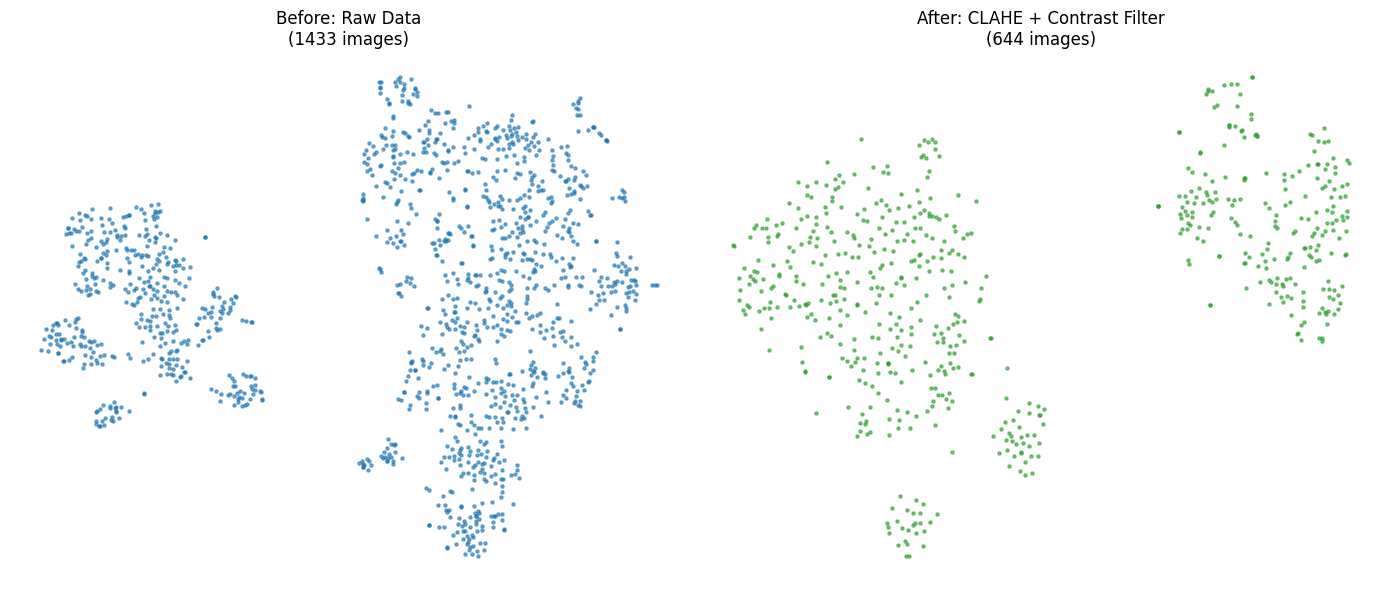

In [30]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# ==========================================
# 1. CONFIGURATION
# ==========================================
# REPLACE THIS with the actual path to your folder containing ONLY 'Good' images

IMG_SIZE = (224, 224)              # Resizing ensures consistent processing speed
CLIP_LIMIT = 2.0                   # CLAHE contrast limit (higher = more contrast)
GRID_SIZE = (8, 8)                 # CLAHE grid size

# Thresholds derived from your histograms:
MIN_CONTRAST_THRESHOLD = 0.08      # Threshold to remove blank/blurry images (std dev < ~20/255)
SIGMA_THRESHOLD = 3                # Z-score threshold for extreme brightness outliers

# ==========================================
# 2. PREPROCESSING FUNCTIONS
# ==========================================

def load_images(path):
    """Loads images from folder and converts to grayscale."""
    images = []
    filenames = []
    valid_extensions = {".png", ".jpg", ".jpeg", ".bmp", ".tif"}
    
    if not os.path.exists(path):
        print(f"Error: Path '{path}' not found.")
        return np.array([]), np.array([])

    for f in os.listdir(path):
        ext = os.path.splitext(f)[1].lower()
        if ext not in valid_extensions:
            continue
            
        img_path = os.path.join(path, f)
        # Load as Grayscale (EL images are monochromatic)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        if img is not None:
            img = cv2.resize(img, IMG_SIZE)
            images.append(img)
            filenames.append(f)
            
    return np.array(images), np.array(filenames)

def apply_refinements(images):
    """
    Applies CLAHE to normalize lighting across the dataset.
    Then normalizes pixel values to 0-1 range.
    """
    refined_images = []
    
    # Create CLAHE object
    clahe = cv2.createCLAHE(clipLimit=CLIP_LIMIT, tileGridSize=GRID_SIZE)
    
    for img in images:
        # Apply CLAHE
        norm_img = clahe.apply(img)
        
        # Normalize pixel values to 0-1 range (Critical for Deep Learning)
        norm_img = norm_img.astype('float32') / 255.0
        
        refined_images.append(norm_img)
        
    return np.array(refined_images)

def filter_outliers(images, filenames):
    """
    Removes images that are:
    1. Too bright/dark (Lighting outliers based on Mean Intensity)
    2. Too flat/blurry (Low contrast outliers based on Std Dev)
    """
    # --- Filter 1: Contrast (Standard Deviation) ---
    # We calculate std dev for each image. Low std dev = flat grey/blank image.
    std_intensities = np.std(images, axis=(1, 2))
    
    # This specifically targets the "Left Cluster" (the flat/blank images)
    contrast_mask = std_intensities > MIN_CONTRAST_THRESHOLD
    
    # --- Filter 2: Brightness (Mean Intensity) ---
    mean_intensities = np.mean(images, axis=(1, 2))
    mean_all = np.mean(mean_intensities)
    std_all = np.std(mean_intensities)
    
    # Keep data within 3 standard deviations of the average brightness
    lower_bound = mean_all - (SIGMA_THRESHOLD * std_all)
    upper_bound = mean_all + (SIGMA_THRESHOLD * std_all)
    brightness_mask = (mean_intensities >= lower_bound) & (mean_intensities <= upper_bound)
    
    # Combine both filters (Image must pass BOTH checks to be kept)
    final_mask = contrast_mask & brightness_mask
    
    # Print stats for user verification
    n_total = len(images)
    n_removed_contrast = np.sum(~contrast_mask)
    n_removed_bright = np.sum(~brightness_mask)
    n_kept = np.sum(final_mask)
    
    print(f"\n--- Filtering Report ---")
    print(f"Total Images: {n_total}")
    print(f"Removed Low Contrast (Blank/Blurry): {n_removed_contrast} (The 'Left Cluster')")
    print(f"Removed Extreme Brightness: {n_removed_bright}")
    print(f"Final Clean Dataset: {n_kept} images")
    
    return images[final_mask], filenames[final_mask]

def plot_comparison(before_imgs, after_imgs):
    """Generates the Before vs. After t-SNE plot."""
    print("\nGenerating t-SNE visualization (this may take a moment)...")
    
    # Setup t-SNE
    # init='pca' helps t-SNE converge faster and be more stable
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
    
    # Flatten data for t-SNE input
    flat_before = before_imgs.reshape(len(before_imgs), -1)
    
    # Sampling for speed if dataset is huge (>5000)
    if len(flat_before) > 5000:
        flat_before = flat_before[:5000]
        
    flat_after = after_imgs.reshape(len(after_imgs), -1)
    if len(flat_after) > 5000:
        flat_after = flat_after[:5000]

    # Compute t-SNE embeddings
    tsne_before = tsne.fit_transform(flat_before)
    tsne_after = tsne.fit_transform(flat_after)

    # Plot results
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.scatter(tsne_before[:, 0], tsne_before[:, 1], s=5, alpha=0.6, c='tab:blue')
    plt.title(f"Before: Raw Data\n({len(flat_before)} images)")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.scatter(tsne_after[:, 0], tsne_after[:, 1], s=5, alpha=0.6, c='tab:green')
    plt.title(f"After: CLAHE + Contrast Filter\n({len(flat_after)} images)")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# ==========================================
# 3. MAIN EXECUTION
# ==========================================

# A. Load
print("Loading raw images...")
raw_images, fnames = load_images(DATA_PATH)

if len(raw_images) > 0:
    # Normalize raw images to 0-1 just for the "Before" plot (so it's a fair comparison)
    raw_images_normalized = raw_images.astype('float32') / 255.0

    # B. Apply CLAHE (Fix Lighting)
    print("Applying CLAHE normalization...")
    processed_images = apply_refinements(raw_images)

    # C. Filter Outliers (Fix "Islands" and "Blank Images")
    print("Filtering outliers...")
    clean_images, clean_fnames = filter_outliers(processed_images, fnames)

    # D. Visualize
    if len(clean_images) > 50: # Only plot if we have enough data left
        plot_comparison(raw_images_normalized, clean_images)
    else:
        print("Not enough images left to plot t-SNE effectively.")
        
    # E. Save Option (Uncomment to save final numpy array for training)
    # np.save("clean_el_train_data.npy", clean_images)
    # print("Cleaned dataset saved to 'clean_el_train_data.npy'")
else:
    print("No images found. Check your DATA_PATH.")

NameError: name 'master_df' is not defined

In [ ]:

# Create Matrices
texture_matrix = master_df.pivot( columns='Class_ID', values='Texture')
contrast_matrix = master_df.pivot( columns='Class_ID', values='Contrast')
aspect_matrix = master_df.pivot( columns='Class_ID', values='Aspect_Ratio')
solidity_matrix = master_df.pivot( columns='Class_ID', values='Solidity')
skew_matrix = master_df.pivot( columns='Class_ID', values='Skewness')
edge_dens_matrix = master_df.pivot( columns='Class_ID', values='Edge_Density')
# count_matrix = master_df.pivot( columns='Class_ID', values='Count')

# print(count_matrix.fillna("-").round(2))


plt.figure(figsize=(16, 20))

# Plot 1: Texture Heatmap
plt.subplot(6, 1, 1)
sns.heatmap(texture_matrix, annot=True, fmt=".1f", cmap='viridis', linewidths=.5)
plt.title('Visual Profile: Texture (Roughness)')

# Plot 2: Contrast Heatmap
plt.subplot(6, 1, 2)
sns.heatmap(contrast_matrix, annot=True, fmt=".1f", cmap='plasma', linewidths=.5)
plt.title('Visual Profile: Contrast (Edge Sharpness)')

plt.subplot(6, 1, 3)
sns.heatmap(aspect_matrix, annot=True, fmt=".1f", linewidths=.5)
plt.title('Visual Profile: Contrast (Edge Sharpness)')


plt.subplot(6, 1, 4)
sns.heatmap(solidity_matrix, annot=True, fmt=".1f", linewidths=.5)
plt.title('Visual Profile: Contrast (Edge Sharpness)')


plt.subplot(6, 1, 5)
sns.heatmap(skew_matrix, annot=True, fmt=".1f", linewidths=.5)
plt.title('Visual Profile: Contrast (Edge Sharpness)')


plt.subplot(6, 1, 6)
sns.heatmap(edge_dens_matrix, annot=True, fmt=".1f", linewidths=.5)
plt.title('Visual Profile: Contrast (Edge Sharpness)')


plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_clusters_with_shapes(raw_df, classes_to_plot=None):
    """
    Plots PCA clusters with both COLOR and SHAPE (Markers).
    You can specify a list of classes to visualize clearly.
    """
    feature_cols = ['Brightness', 'Texture', 'Contrast', 'Aspect_Ratio', 'Solidity', 'Skewness', 'Edge_Density']
    # feature_cols = ['Mean_Brightness', 'Mean_Texture', 'Mean_Contrast', 'Mean_Aspect_Ratio', 'Mean_Solidity', 'Mean_Skewness', 'Mean_Edge_Density']
    
    # 1. Standardize & PCA
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA
    
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(raw_df[feature_cols])
    
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(scaled_data)
    
    df_viz = raw_df.copy()
    df_viz['pca1'] = pca_result[:, 0]
    df_viz['pca2'] = pca_result[:, 1]

    # 2. Filter Classes (Optional but Recommended)
    # If no list provided, take top 6 most frequent classes to keep chart readable
    if classes_to_plot is None:
        top_classes = df_viz['Class_ID'].value_counts().index[:
                                                              ]
        df_viz = df_viz[df_viz['Class_ID'].isin(top_classes)]
        title_suffix = f"(Top 6 Classes)"
    else:
        df_viz = df_viz[df_viz['Class_ID'].isin(classes_to_plot)]
        title_suffix = f"(Selected Classes: {classes_to_plot})"

    # 3. Define Custom Markers (Shapes)
    # We map specific classes to specific markers for clarity
    # List of available matplotlib markers: 'o', 'X', 's', 'P', 'D', '^', 'v', '<', '>'
    unique_classes = df_viz['Class_ID'].unique()
    markers_list = ['o', 'X', 's', 'P', 'D', '^', 'v', '<', '>', 'p', '*', 'h', 'H', '+', 'x', 'd', '|', '_']
    
    # Create a dictionary mapping Class -> Marker
    # If you have more classes than markers, matplotlib will cycle, but this gives control
    markers_dict = {cls: markers_list[i % len(markers_list)] for i, cls in enumerate(unique_classes)}

    # 4. Plot
    plt.figure(figsize=(14, 10))
    
    # style='Class_ID' adds the shapes
    # markers=markers_dict forces the specific shapes
    # alpha=0.6 makes dots transparent so you can see density/overlaps
    sns.scatterplot(
        data=df_viz, 
        x='pca1', 
        y='pca2', 
        hue='Class_ID', 
        style='Class_ID',
        # markers=markers_dict,
        palette='bright',   # Use 'bright' or 'tab10' for better contrast
        s=60,               # Size of the dots
        alpha=0.6,          # Transparency
        edgecolor=None       # Removes border on dots
    )
    
    plt.title(f'PCA Clustering with Shapes & Colors {title_suffix}')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
    
    # Move legend outside
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Class')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

# --- USAGE EXAMPLES ---

# Example 1: Plot Top 6 classes (Automatically selected)
# plot_clusters_with_shapes(raw_df)

# Example 2: Compare specific groups you care about
# Let's say you want to see how "Clean" compares against "Cracks" and "Spots"
plot_clusters_with_shapes(master_df)

### identify model architecture

In [8]:
import torch
import os
import glob
import pathlib
import sys


if sys.platform == 'win32':
    pathlib.PosixPath = pathlib.WindowsPath


In [19]:
folder_path = r"D:\Rowan\solarguard-ai - Copy\backend-nodejs\models"
# def inspect_patchcore_objects(folder_path):
model_files = glob.glob(os.path.join(folder_path, "*.pt")) + glob.glob(os.path.join(folder_path, "*.pth"))

# if not model_files:
#     print("No model files found.")
#     return

for file_path in model_files:
    if 'best' in file_path:
        continue
    if 'model.pt' not in file_path:
        continue
    
    print(f"--- FILE: {os.path.basename(file_path)} ({os.path.getsize(file_path) / 1024**2:.2f} MB) ---")

    # Load the checkpoint
    checkpoint = torch.load(file_path, map_location='cpu', weights_only=False)
    print(checkpoint)
    
    # Check if the standard 'model' key exists
    if "model" in checkpoint:
        inner = checkpoint["model"]
        print(inner)
        break
        # 1. Handle if it's a Dictionary (Standard State Dict)
        if isinstance(inner, dict):
            print("Type: Dictionary (State Dict)")
            if "memory_bank" in inner:
                print(f"  Memory Bank Shape: {inner['memory_bank'].shape}")

        # 2. Handle if it's an OBJECT (The actual PatchCore Class) - This is your case
        else:
            print("Type: Python Object (PatchCore Instance)")
            
            # A. Check Memory Bank
            if hasattr(inner, "memory_bank") and inner.memory_bank is not None:
                print(f"  Memory Bank Shape: {inner.memory_bank.shape}")
            else:
                print("  Memory Bank: Empty or Not Found")

            # B. Check Sampling Ratio (Crucial for PatchCore)
            # 0.01 is default, 1.0 is "coreset subsampling disabled" (slower, usually better)
            if hasattr(inner, "sampling_ratio"):
                print(f"  Sampling Ratio: {inner.sampling_ratio}")

            # C. Check Backbone Name
            if hasattr(inner, "backbone"):
                # Get the class name of the backbone (e.g., ResNet18, WideResNet50)
                backbone_name = type(inner.backbone).__name__
                print(f"  Backbone: {backbone_name}")

            # D. Check number of neighbors (k)
            if hasattr(inner, "nn_k"):
                print(f"  Neighbors (k): {inner.nn_k}")

    else:
        print("Could not find 'model' key in checkpoint.")

    print("\n")

    

--- FILE: model.pt (148.40 MB) ---
{'model': Patchcore(
  (pre_processor): PreProcessor(
    (transform): Compose(
          Resize(size=[256, 256], interpolation=InterpolationMode.BILINEAR, antialias=True)
          Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
    )
    (export_transform): Compose(
          Resize(size=[256, 256], interpolation=InterpolationMode.BILINEAR, antialias=False)
          Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
    )
  )
  (post_processor): PostProcessor(
    (_image_threshold_metric): F1AdaptiveThreshold()
    (_pixel_threshold_metric): F1AdaptiveThreshold()
    (_image_min_max_metric): MinMax()
    (_pixel_min_max_metric): MinMax()
  )
  (evaluator): Evaluator(
    (val_metrics): ModuleList()
    (test_metrics): ModuleList(
      (0): AUROC()
      (1): F1Score()
      (2): AUROC()
      (3): F1Score()
    )
  )
  (model): PatchcoreModel(
    (feature_extractor): TimmFeatureExtract

In [13]:
# USAGE: Change the path to your folder containing the models
inspect_patchcore_objects(r"D:\Rowan\solarguard-ai - Copy\backend-nodejs\models") 

--- FILE: best.pt (49.62 MB) ---
Type: Python Object (PatchCore Instance)
  Memory Bank: Empty or Not Found


--- FILE: best2.pt (5.96 MB) ---
Type: Python Object (PatchCore Instance)
  Memory Bank: Empty or Not Found


--- FILE: cell_anomaly_old.pt (148.40 MB) ---
Type: Python Object (PatchCore Instance)
  Memory Bank: Empty or Not Found


--- FILE: defect_detector.pt (42.76 MB) ---
Type: Python Object (PatchCore Instance)
  Memory Bank: Empty or Not Found


--- FILE: model.pt (148.40 MB) ---
Type: Python Object (PatchCore Instance)
  Memory Bank: Empty or Not Found




In [20]:
import torch

# Load your file
print(f"Loading {file_path}...")
checkpoint = torch.load(file_path, map_location='cpu', weights_only=False)

# Access the Patchcore object (based on your output, it's inside the 'model' key)
patchcore_model = checkpoint['model']

# We need to access the inner 'model' which contains the Patchcore logic
# Structure is usually: Patchcore(wrapper) -> PatchcoreModel(logic)
core_model = patchcore_model.model

print("\n--- MODEL PARAMETERS ---")

# 1. Memory Bank Size (The most important part)
if hasattr(core_model, 'memory_bank') and core_model.memory_bank is not None:
    print(f"Memory Bank Shape: {core_model.memory_bank.shape}")
    print(f"  -> Number of patches stored: {core_model.memory_bank.shape[0]}")
    print(f"  -> Feature dimension: {core_model.memory_bank.shape[1]}")
else:
    print("Memory Bank: Not found or empty.")

# 2. Number of Neighbors (k)
# How similar patches are compared. Default is usually 9.
if hasattr(core_model, 'nn_k'):
    print(f"K-Nearest Neighbors (k): {core_model.nn_k}")
elif hasattr(core_model, 'k'): # Some versions use just 'k'
    print(f"K-Nearest Neighbors (k): {core_model.k}")

# 3. Sampling Ratio
# Did you sample 1% (0.01) of patches or 100% (1.0)?
if hasattr(core_model, 'sampling_ratio'):
    print(f"Sampling Ratio: {core_model.sampling_ratio}")

# 4. Backbone Name
if hasattr(patchcore_model, 'backbone'):
    # This might print the object, let's try to get the string name if possible
    print(f"Backbone Config: {patchcore_model.backbone}")

print("\n--- ANALYSIS ---")
if hasattr(core_model, 'memory_bank') and core_model.memory_bank is not None:
    num_patches = core_model.memory_bank.shape[0]
    if num_patches > 50000:
        print("Verdict: This is a HIGH-CAPACITY model (Large Memory Bank).")
        print("It is likely your 'Final Best' model if you trained for accuracy.")
    else:
        print("Verdict: This is a COMPACT model (Small Memory Bank).")
        print("It is likely a 'Fast' prototype model.")

Loading D:\Rowan\solarguard-ai - Copy\backend-nodejs\models\model.pt...

--- MODEL PARAMETERS ---
Memory Bank Shape: torch.Size([94003, 384])
  -> Number of patches stored: 94003
  -> Feature dimension: 384

--- ANALYSIS ---
Verdict: This is a HIGH-CAPACITY model (Large Memory Bank).
It is likely your 'Final Best' model if you trained for accuracy.


In [26]:
checkpoint['model'].post_processor._pixel_threshold_metric.value


AttributeError: 'F1AdaptiveThreshold' object has no attribute 'value'

In [27]:


print(f"Inspecting {file_path} for threshold values...\n")

try:
    # Load the checkpoint
    ckpt = torch.load(file_path, map_location='cpu', weights_only=False)
    
    # 1. CHECK: Top-level keys (Most common place)
    # Anomalib often saves the best thresholds here directly
    print("--- Top Level Checkpoint Data ---")
    if "image_threshold" in ckpt:
        print(f"✓ Image Threshold Found: {ckpt['image_threshold']}")
    else:
        print("✗ No 'image_threshold' at root level.")

    if "pixel_threshold" in ckpt:
        print(f"✓ Pixel Threshold Found: {ckpt['pixel_threshold']}")
    else:
        print("✗ No 'pixel_threshold' at root level.")

    # 2. CHECK: Inside the Model Object (If saved as full object)
    # Sometimes the value lives inside the post_processor itself
    if "model" in ckpt:
        model_obj = ckpt['model']
        if hasattr(model_obj, 'post_processor'):
            pp = model_obj.post_processor
            
            print("\n--- Inside Post Processor ---")
            
            # Try to access the adaptive threshold object directly
            img_thresh_obj = pp._image_threshold_metric
            pix_thresh_obj = pp._pixel_threshold_metric
            
            # Check if they have a .value attribute
            if hasattr(img_thresh_obj, 'value'):
                print(f"✓ Image Threshold (Internal): {img_thresh_obj.value}")
            elif hasattr(img_thresh_obj, 'threshold'):
                print(f"✓ Image Threshold (Internal): {img_thresh_obj.threshold}")
            else:
                # If not found, try to see what attributes it DOES have
                print(f"✗ Value not stored in object. Attributes available: {dir(img_thresh_obj)}")

except Exception as e:
    print(f"Error: {e}")

Inspecting D:\Rowan\solarguard-ai - Copy\backend-nodejs\models\model.pt for threshold values...

--- Top Level Checkpoint Data ---
✗ No 'image_threshold' at root level.
✗ No 'pixel_threshold' at root level.

--- Inside Post Processor ---
✗ Value not stored in object. Attributes available: ['T_destination', '_TORCH_GREATER_EQUAL_2_1', '__abs__', '__abstractmethods__', '__add__', '__and__', '__annotations__', '__call__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__floordiv__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getnewargs__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__inv__', '__invert__', '__iter__', '__jit_ignored_attributes__', '__jit_unused_properties__', '__le__', '__lt__', '__matmul__', '__mod__', '__module__', '__mul__', '__ne__', '__neg__', '__new__', '__or__', '__pos__', '__pow__', '__radd__', '__rand__', '__reduce__', '__reduce_ex__', '__repr__', '__rfloordiv__', '__rmatmul__

In [ ]:
ckpt = torch.load(file_path, map_location='cpu', weights_only=False)
model_obj = ckpt['model']
pp = model_obj.post_processor
img_thresh = pp._image_threshold_metric

print("--- 1. Checking Specific Attributes ---")
# These are the most likely places the number is hiding
targets = ['thresholds', 'value', 'best_threshold', 'threshold_value', 'optimal_threshold', 'f1_score']

found_any = False
for t in targets:
    if hasattr(img_thresh, t):
        val = getattr(img_thresh, t)
        print(f"✓ Found attribute '{t}': {val}")
        found_any = True

if not found_any:
    print("✗ None of the common attributes found a value.")

print("\n--- 2. Checking State Dictionary (Internal Storage) ---")
# Metrics often store their final calculated values in the state_dict
state = img_thresh.state_dict()

if not state:
    print("✗ State dictionary is empty.")
else:
    for key, value in state.items():
        print(f"Key: '{key}' | Value: {value}")
        # If we find a tensor that looks like a single number threshold
        if hasattr(value, 'numel') and value.numel() == 1:
            print(f"  >>> This looks like a single number threshold! <<<")

--- 1. Checking Specific Attributes ---
✓ Found attribute 'thresholds': None

--- 2. Checking State Dictionary (Internal Storage) ---
✗ State dictionary is empty.
